In [1]:
import copy
import functools
import glob
import math
import pickle
import scipy
import sklearn
import warnings

warnings.filterwarnings('ignore')

import itertools
import graphviz as gr
import numpy as np
import os
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import seaborn as sns


from matplotlib import style
from matplotlib import pyplot as plt
from pprint import pprint
from scipy import stats, special
from sklearn import datasets, mixture
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

from scipy.stats import ttest_ind


from urllib.request import urlopen
import json
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)

import plotly.express as px
import plotly.figure_factory as ff

%matplotlib inline

style.use("fivethirtyeight")
pd.set_option("display.max_columns", 6)

np.random.seed(0)
pd.set_option('display.max_columns', None)

import dask
import dask.dataframe as dd
from dask.distributed import Client


In [2]:
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', None)

### Binary Classification

In [119]:
def binary_classification_performance(df, date_col="date", outcome_col="delta_ranked", predictor_col="TLGRF_decision"):
    # Compute TP, TN, FP, FN
    selected_df = df[df[predictor_col]!=0]
    
    not_selected_df = df[df[predictor_col]==0]
    
    Results_Thresh = pd.DataFrame()
    #Total
    Total_Decision_Set = df.groupby(date_col)[outcome_col].count()
    Results_Thresh["Total"] = Total_Decision_Set
    #P
    #P = df.groupby(date_col)["capacity"].max()
    
    #TP
    TP = selected_df.groupby(date_col).apply(lambda x: (x[outcome_col] <= x["capacity"]).sum())
    Results_Thresh["TP"] = TP
    #FP = FN
    FP = selected_df.groupby(date_col).apply(lambda x: (x[outcome_col] > x["capacity"]).sum())
    Results_Thresh["FP"] = FP
    
    FN = not_selected_df.groupby(date_col).apply(lambda x: (x[outcome_col] <= x["capacity"]).sum())
    Results_Thresh["FN"] = FN
    #N
    TN = not_selected_df.groupby(date_col).apply(lambda x: (x[outcome_col] > x["capacity"]).sum())
    Results_Thresh["TN"] = TN
    
    Results_Thresh["P"] = TP + FN
    Results_Thresh["N"] = TN + FP
    #Results_Thresh["TN"] = Results_Thresh["N"] - Results_Thresh["FP"]
    #TN
    Results_Thresh = Results_Thresh[["Total", "P", "N", "TP", "FP", "FN", "TN"]]
    
    TP = Results_Thresh.sum()["TP"]
    FP = Results_Thresh.sum()["FP"]
    FN = Results_Thresh.sum()["FN"]
    TN = Results_Thresh.sum()["TN"]


    PPV = Results_Thresh.sum()["TP"]/(Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FP"])
    FPV = Results_Thresh.sum()["FP"]/(Results_Thresh.sum()["TN"] + Results_Thresh.sum()["FP"])
    TPR = Results_Thresh.sum()["TP"]/(Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FN"])
    TNR = Results_Thresh.sum()["TN"]/(Results_Thresh.sum()["TN"] + Results_Thresh.sum()["FP"])

    Precision = Results_Thresh.sum()["TP"] / (Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FP"])
    Recall = Results_Thresh.sum()["TP"] / (Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FN"])
    F1 = 2 * Precision * Recall / (Precision + Recall)

    # create a pandas dataframe from the confusion matrix values
    confusion_table = pd.DataFrame({'actual_positive': [1, 1, 0, 0], 'predicted_positive': [0, 1, 0, 1], 'count': [FN, TP, TN, FP]})

    # create a pivot table to represent the confusion matrix
    confusion_matrix = pd.pivot_table(confusion_table, values='count', index=['actual_positive'], columns=['predicted_positive'])

    # set the column and index names of the pivot table
    confusion_matrix.columns.name = 'Predicted Label'
    confusion_matrix.index.name = 'Actual Label'
    #confusion_matrix = confusion_matrix.T


    print("PPV={}, FPV={}\nTPR={}, TNR={}\nF1={}".format(PPV, FPV, TPR, TNR, F1))
    print(Results_Thresh.sum())
    confusion_matrix
    
    return Results_Thresh, (PPV, FPV, TPR, TNR, F1), confusion_matrix

In [126]:
def binary_classification_performance_counter(df, date_col="date", outcome_col="delta_ranked", predictor="TLGRF"):
    # Compute TP, TN, FP, FN
    
    assert predictor in {"CDPHE", "TLGRF"}
        
    Results_Thresh = pd.DataFrame()
    #Total
    Total_Decision_Set = df.groupby(date_col)[outcome_col].count()
    Results_Thresh["Total"] = Total_Decision_Set
    #P
    #P = df.groupby(date_col)["capacity"].max()
    
    #TP
    Results_Thresh["TP"] = df.groupby(date_col)[predictor + "_TP"].sum()
    #FP
    Results_Thresh["FP"] = df.groupby(date_col)[predictor + "_FP"].sum()
    #FN
    Results_Thresh["FN"] = df.groupby(date_col)[predictor + "_FN"].sum()
    #TN
    Results_Thresh["TN"] = df.groupby(date_col)[predictor + "_TN"].sum()
    
    Results_Thresh["P"] = Results_Thresh["TP"] + Results_Thresh["FN"]
    Results_Thresh["N"] = Results_Thresh["TN"] + Results_Thresh["FP"]
    #Results_Thresh["TN"] = Results_Thresh["N"] - Results_Thresh["FP"]
    #TN
    Results_Thresh = Results_Thresh[["Total", "P", "N", "TP", "FP", "FN", "TN"]]
    
    TP = Results_Thresh.sum()["TP"]
    FP = Results_Thresh.sum()["FP"]
    FN = Results_Thresh.sum()["FN"]
    TN = Results_Thresh.sum()["TN"]


    PPV = Results_Thresh.sum()["TP"]/(Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FP"])
    FPV = Results_Thresh.sum()["FP"]/(Results_Thresh.sum()["TN"] + Results_Thresh.sum()["FP"])
    TPR = Results_Thresh.sum()["TP"]/(Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FN"])
    TNR = Results_Thresh.sum()["TN"]/(Results_Thresh.sum()["TN"] + Results_Thresh.sum()["FP"])

    Precision = Results_Thresh.sum()["TP"] / (Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FP"])
    Recall = Results_Thresh.sum()["TP"] / (Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FN"])
    F1 = 2 * Precision * Recall / (Precision + Recall)

    # create a pandas dataframe from the confusion matrix values
    confusion_table = pd.DataFrame({'actual_positive': [1, 1, 0, 0], 'predicted_positive': [0, 1, 0, 1], 'count': [FN, TP, TN, FP]})

    # create a pivot table to represent the confusion matrix
    confusion_matrix = pd.pivot_table(confusion_table, values='count', index=['actual_positive'], columns=['predicted_positive'])

    # set the column and index names of the pivot table
    confusion_matrix.columns.name = 'Predicted Label'
    confusion_matrix.index.name = 'Actual Label'
    #confusion_matrix = confusion_matrix.T


    print("PPV={}, FPV={}\nTPR={}, TNR={}\nF1={}".format(PPV, FPV, TPR, TNR, F1))
    print(Results_Thresh.sum())
    confusion_matrix
    
    return Results_Thresh, (PPV, FPV, TPR, TNR, F1), confusion_matrix

In [4]:
DATA_FOLDER = "../data"
COLORADO_DATA_FOLDER = os.path.join(DATA_FOLDER,"Colorado_Data")
COLORADO_DF_PATH = os.path.join(DATA_FOLDER,"colorado_outbreaks_2023-04-26.csv")
MASTER_FIPS_PATH = os.path.join(COLORADO_DATA_FOLDER,"county_fips_master.csv")

### Import Outbreak and Changepoint Matrices

In [5]:
changepoint_matrix = pd.read_csv("../data/changepoint_matrix.csv")
outbreak_matrix = pd.read_csv("../data/colorado_outbreak_matrix.csv")

In [6]:
outbreak_matrix_df = pd.melt(outbreak_matrix, id_vars=["fips"], var_name='datetime', value_name="outbreak")
outbreak_matrix_df["fips"] = outbreak_matrix_df["fips"].astype('int64')
outbreak_matrix_df["datetime"] = pd.to_datetime(outbreak_matrix_df["datetime"])
#outbreak_matrix_df

In [7]:
changepoint_panel_df = pd.melt(changepoint_matrix, id_vars=["Unnamed: 0"], var_name='datetime', value_name="changepoint")
changepoint_panel_df = changepoint_panel_df.fillna(0)
changepoint_panel_df = changepoint_panel_df.rename(columns={"Unnamed: 0": "datetime", "datetime": "fips"})
changepoint_panel_df["datetime"] = pd.to_datetime(changepoint_panel_df["datetime"])
changepoint_panel_df["fips"] = changepoint_panel_df["fips"].astype('int64')
changepoint_panel_df = changepoint_panel_df[changepoint_panel_df["datetime"] <= "2022-12-31"]
changepoint_panel_df.loc[changepoint_panel_df['changepoint'] < 0, 'changepoint'] = 0
#changepoint_panel_df

In [8]:
capacity_df = pd.DataFrame(changepoint_panel_df[changepoint_panel_df["changepoint"] > 0].groupby("datetime")["changepoint"].sum())
capacity_df.index = pd.to_datetime(capacity_df.index)
capacity_df = capacity_df.resample('1D').asfreq()
capacity_df = capacity_df.fillna(0)
capacity_df = capacity_df.reset_index()
capacity_df = capacity_df.rename(columns={"changepoint":"capacity"})

merged_changepoint_outbreak_df = pd.merge(changepoint_panel_df, outbreak_matrix_df, on=["datetime","fips"])
merged_changepoint_outbreak_df = pd.merge(merged_changepoint_outbreak_df, capacity_df, on=["datetime"], how="left")
merged_changepoint_outbreak_df["capacity"] = merged_changepoint_outbreak_df["capacity"].fillna(0)
merged_changepoint_outbreak_df

,datetime,fips,changepoint,outbreak,capacity
0,2020-03-17,8001,0.0,0,0.0
1,2020-03-18,8001,0.0,0,1.0
2,2020-03-19,8001,0.0,0,1.0
3,2020-03-20,8001,0.0,0,1.0
4,2020-03-21,8001,0.0,0,0.0
...,...,...,...,...,...
65275,2022-12-27,8125,0.0,1,0.0
65276,2022-12-28,8125,0.0,1,0.0
65277,2022-12-29,8125,0.0,1,0.0
65278,2022-12-30,8125,0.0,1,2.0


In [9]:
capacity_df

,datetime,capacity
0,2020-03-18,1.0
1,2020-03-19,1.0
2,2020-03-20,1.0
3,2020-03-21,0.0
4,2020-03-22,0.0
...,...,...
1013,2022-12-26,0.0
1014,2022-12-27,0.0
1015,2022-12-28,0.0
1016,2022-12-29,0.0


In [10]:
DP_dates = sorted(merged_changepoint_outbreak_df[merged_changepoint_outbreak_df["capacity"] > 0]["datetime"].unique())
merged_changepoint_outbreak_df[merged_changepoint_outbreak_df["datetime"].isin(DP_dates)]

,datetime,fips,changepoint,outbreak,capacity
1,2020-03-18,8001,0.0,0,1.0
2,2020-03-19,8001,0.0,0,1.0
3,2020-03-20,8001,0.0,0,1.0
6,2020-03-23,8001,1.0,1,2.0
8,2020-03-25,8001,0.0,1,1.0
...,...,...,...,...,...
65260,2022-12-12,8125,0.0,1,1.0
65264,2022-12-16,8125,0.0,1,1.0
65268,2022-12-20,8125,0.0,1,1.0
65271,2022-12-23,8125,0.0,1,1.0


In [11]:
merged_changepoint_outbreak_df[merged_changepoint_outbreak_df["changepoint"] < 0]

,datetime,fips,changepoint,outbreak,capacity


In [12]:
merged_changepoint_outbreak_df[(merged_changepoint_outbreak_df["datetime"]=="2020-03-19") & (merged_changepoint_outbreak_df["changepoint"] == 1)]

,datetime,fips,changepoint,outbreak,capacity
6122,2020-03-19,8013,1.0,1,1.0


### Import Colorado Historical Data

In [13]:
### Load in Combined Census Data
augmented_data_path = "../../data/augmented_us-counties-states_latest.csv"
#augmented_df = (dd.read_csv(augmented_data_path, assume_missing=True)).compute()
augmented_df = (dd.read_csv(augmented_data_path, assume_missing=True))
augmented_colorado_df = augmented_df[augmented_df["state"]=="Colorado"]
augmented_colorado_df = augmented_colorado_df.compute()
augmented_colorado_df = augmented_colorado_df.sort_values(by=["date","fips"])
cols_to_drop = augmented_colorado_df.columns[augmented_colorado_df.nunique()==1]
reduced_augmented_colorado_df = augmented_colorado_df.drop(cols_to_drop, axis=1)
reduced_augmented_colorado_df

,fips,date,county,cases,deaths,datetime,days_from_start,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,State_of_emergency_issued,State_of_emergency_lifted,Date_closed_K-12_public_schools,Date_banned_visitors_to_nursing_homes,Stay_at_home/_shelter_in_place,End/relax_stay_at_home/shelter_in_place,Closed_other_non-essential_businesses,Began_to_reopen_businesses,Face_mask_mandate_in_public_spaces,Face_mask_mandate_for_employees_of_public-facing_businesses,Ended_face_mask_mandate,Allowed_restaurants_to_sell_takeout_alcohol,Allowed_restaurants_to_deliver_alcohol,Closed_restaurants_except_take_out,Reopen_restaurants,Closed_gyms,Reopened_gyms,Closed_movie_theaters,Reopened_movie_theaters,Closed_Bars,Reopen_bars,Reopened_hair_salons/barber_shops,Reopened_religious_gatherings,Reopened_other_non-essential_retail,Began_to_reclose_bars,Closed_bars_(x2),Reopened_bars_(x2),Date_vaccine_allocation_plan_last_updated,Vaccine_allocation_phase:_Frontline_Healthcare_Workers,Vaccine_allocation_phase:_Healthcare_Service_Workers,Vaccine_allocation_phase:_Home_Healthcare_Workers,Vaccine_allocation_phase:_Additional_Healthcare_Workers,Vaccine_allocation_phase:_Long-term_Care_Residents,Vaccine_allocation_phase:_EMS_Providers,Vaccine_allocation_phase:_Firefighters,Vaccine_allocation_phase:_Law_Enforcement_&_Public_Safety_Personnel,Vaccine_allocation_phase:_Correctional_Staff,Vaccine_allocation_phase:_Adults_Ages_75+,Vaccine_allocation_phase:_Adults_Ages_65+,Vaccine_allocation_phase:_Adults_w/_High-Risk_Medical_Conditions,Vaccine_allocation_phase:_Pre-K-12_School_Employees,Vaccine_allocation_phase:_Higher_Education_Employees,Vaccine_allocation_phase:_Public_Transit_Workers,Vaccine_allocation_phase:_Food_Supply_Workers,Vaccine_allocation_phase:_Grocery_Store_Workers,Vaccine_allocation_phase:_Frontline_Essential_Workers,Vaccine_allocation_phase:_Additional_Essential_Workers,Date_adults_ages_80+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_75+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_70+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_65+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_60+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_55+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_50+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_45+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_40+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_30+_became_eligible_for_COVID-19_vaccination,Date_K-12_school_employees_became_eligible_for_COVID-19_vaccination,Date_grocery_store_workers_became_eligible_for_COVID-19_vaccination,Date_incarcerated_people_became_eligible_for_COVID-19_vaccination,Date_general_public_became_eligible_for_COVID-19_vaccination,First_overall_eviction_moratorium_start,First_overall_eviction_moratorium_end,Second_overall_eviction_moratorium_start,Second_overall_eviction_moratorium_end,First_eviction_initiation_ban_start,First_eviction_initiation_ban_end,Second_Eviction_Initiation_Ban_Start,Second_Eviction_Initiation_Ban_End,First_eviction_enforcement_ban_start,First_eviction_enforcement_ban_end,Second_Evictio

In [14]:
reduced_augmented_colorado_df["date"] = pd.to_datetime(reduced_augmented_colorado_df["date"])
reduced_augmented_colorado_df["datetime"] = pd.to_datetime(reduced_augmented_colorado_df["datetime"])

reduced_augmented_colorado_df["shifted_rolled_cases"] = reduced_augmented_colorado_df["rolled_cases"].shift(-7)
reduced_augmented_colorado_df["delta cases"] = reduced_augmented_colorado_df["shifted_rolled_cases"] - reduced_augmented_colorado_df["rolled_cases"]
reduced_augmented_colorado_df

,fips,date,county,cases,deaths,datetime,days_from_start,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,State_of_emergency_issued,State_of_emergency_lifted,Date_closed_K-12_public_schools,Date_banned_visitors_to_nursing_homes,Stay_at_home/_shelter_in_place,End/relax_stay_at_home/shelter_in_place,Closed_other_non-essential_businesses,Began_to_reopen_businesses,Face_mask_mandate_in_public_spaces,Face_mask_mandate_for_employees_of_public-facing_businesses,Ended_face_mask_mandate,Allowed_restaurants_to_sell_takeout_alcohol,Allowed_restaurants_to_deliver_alcohol,Closed_restaurants_except_take_out,Reopen_restaurants,Closed_gyms,Reopened_gyms,Closed_movie_theaters,Reopened_movie_theaters,Closed_Bars,Reopen_bars,Reopened_hair_salons/barber_shops,Reopened_religious_gatherings,Reopened_other_non-essential_retail,Began_to_reclose_bars,Closed_bars_(x2),Reopened_bars_(x2),Date_vaccine_allocation_plan_last_updated,Vaccine_allocation_phase:_Frontline_Healthcare_Workers,Vaccine_allocation_phase:_Healthcare_Service_Workers,Vaccine_allocation_phase:_Home_Healthcare_Workers,Vaccine_allocation_phase:_Additional_Healthcare_Workers,Vaccine_allocation_phase:_Long-term_Care_Residents,Vaccine_allocation_phase:_EMS_Providers,Vaccine_allocation_phase:_Firefighters,Vaccine_allocation_phase:_Law_Enforcement_&_Public_Safety_Personnel,Vaccine_allocation_phase:_Correctional_Staff,Vaccine_allocation_phase:_Adults_Ages_75+,Vaccine_allocation_phase:_Adults_Ages_65+,Vaccine_allocation_phase:_Adults_w/_High-Risk_Medical_Conditions,Vaccine_allocation_phase:_Pre-K-12_School_Employees,Vaccine_allocation_phase:_Higher_Education_Employees,Vaccine_allocation_phase:_Public_Transit_Workers,Vaccine_allocation_phase:_Food_Supply_Workers,Vaccine_allocation_phase:_Grocery_Store_Workers,Vaccine_allocation_phase:_Frontline_Essential_Workers,Vaccine_allocation_phase:_Additional_Essential_Workers,Date_adults_ages_80+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_75+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_70+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_65+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_60+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_55+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_50+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_45+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_40+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_30+_became_eligible_for_COVID-19_vaccination,Date_K-12_school_employees_became_eligible_for_COVID-19_vaccination,Date_grocery_store_workers_became_eligible_for_COVID-19_vaccination,Date_incarcerated_people_became_eligible_for_COVID-19_vaccination,Date_general_public_became_eligible_for_COVID-19_vaccination,First_overall_eviction_moratorium_start,First_overall_eviction_moratorium_end,Second_overall_eviction_moratorium_start,Second_overall_eviction_moratorium_end,First_eviction_initiation_ban_start,First_eviction_initiation_ban_end,Second_Eviction_Initiation_Ban_Start,Second_Eviction_Initiation_Ban_End,First_eviction_enforcement_ban_start,First_eviction_enforcement_ban_end,Second_Evictio

In [15]:
decision_w_augmented_data = pd.merge(merged_changepoint_outbreak_df[merged_changepoint_outbreak_df["capacity"] > 0], reduced_augmented_colorado_df, left_on=["datetime","fips"], right_on=["datetime","fips"], how="inner")
# Filter out black counties that are not changepoints
decision_w_augmented_data = decision_w_augmented_data[(decision_w_augmented_data["changepoint"] == 1)|(decision_w_augmented_data["outbreak"] == 0)]
decision_w_augmented_data["delta_ranked"] = decision_w_augmented_data.groupby("date")["delta cases"].rank(method="dense", ascending=False)
# Eliminate El Paso fips=8041
decision_w_augmented_data = decision_w_augmented_data[decision_w_augmented_data["fips"] != 8041]


decision_w_augmented_data

,datetime,fips,changepoint,outbreak,capacity,date,county,cases,deaths,days_from_start,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,State_of_emergency_issued,State_of_emergency_lifted,Date_closed_K-12_public_schools,Date_banned_visitors_to_nursing_homes,Stay_at_home/_shelter_in_place,End/relax_stay_at_home/shelter_in_place,Closed_other_non-essential_businesses,Began_to_reopen_businesses,Face_mask_mandate_in_public_spaces,Face_mask_mandate_for_employees_of_public-facing_businesses,Ended_face_mask_mandate,Allowed_restaurants_to_sell_takeout_alcohol,Allowed_restaurants_to_deliver_alcohol,Closed_restaurants_except_take_out,Reopen_restaurants,Closed_gyms,Reopened_gyms,Closed_movie_theaters,Reopened_movie_theaters,Closed_Bars,Reopen_bars,Reopened_hair_salons/barber_shops,Reopened_religious_gatherings,Reopened_other_non-essential_retail,Began_to_reclose_bars,Closed_bars_(x2),Reopened_bars_(x2),Date_vaccine_allocation_plan_last_updated,Vaccine_allocation_phase:_Frontline_Healthcare_Workers,Vaccine_allocation_phase:_Healthcare_Service_Workers,Vaccine_allocation_phase:_Home_Healthcare_Workers,Vaccine_allocation_phase:_Additional_Healthcare_Workers,Vaccine_allocation_phase:_Long-term_Care_Residents,Vaccine_allocation_phase:_EMS_Providers,Vaccine_allocation_phase:_Firefighters,Vaccine_allocation_phase:_Law_Enforcement_&_Public_Safety_Personnel,Vaccine_allocation_phase:_Correctional_Staff,Vaccine_allocation_phase:_Adults_Ages_75+,Vaccine_allocation_phase:_Adults_Ages_65+,Vaccine_allocation_phase:_Adults_w/_High-Risk_Medical_Conditions,Vaccine_allocation_phase:_Pre-K-12_School_Employees,Vaccine_allocation_phase:_Higher_Education_Employees,Vaccine_allocation_phase:_Public_Transit_Workers,Vaccine_allocation_phase:_Food_Supply_Workers,Vaccine_allocation_phase:_Grocery_Store_Workers,Vaccine_allocation_phase:_Frontline_Essential_Workers,Vaccine_allocation_phase:_Additional_Essential_Workers,Date_adults_ages_80+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_75+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_70+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_65+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_60+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_55+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_50+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_45+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_40+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_30+_became_eligible_for_COVID-19_vaccination,Date_K-12_school_employees_became_eligible_for_COVID-19_vaccination,Date_grocery_store_workers_became_eligible_for_COVID-19_vaccination,Date_incarcerated_people_became_eligible_for_COVID-19_vaccination,Date_general_public_became_eligible_for_COVID-19_vaccination,First_overall_eviction_moratorium_start,First_overall_eviction_moratorium_end,Second_overall_eviction_moratorium_start,Second_overall_eviction_moratorium_end,First_eviction_initiation_ban_start,First_eviction_initiation_ban_end,Second_Eviction_Initiation_Ban_Start,Second_Eviction_Initiation_Ban_End,First_eviction_enforcement_ban_start,First_eviction_enfo

In [16]:
not_enough_data_ranked = decision_w_augmented_data[(decision_w_augmented_data["delta_ranked"].isna()) & (decision_w_augmented_data["changepoint"]==1)]
drop_dates = not_enough_data_ranked["datetime"].unique()
not_enough_data_ranked

,datetime,fips,changepoint,outbreak,capacity,date,county,cases,deaths,days_from_start,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,State_of_emergency_issued,State_of_emergency_lifted,Date_closed_K-12_public_schools,Date_banned_visitors_to_nursing_homes,Stay_at_home/_shelter_in_place,End/relax_stay_at_home/shelter_in_place,Closed_other_non-essential_businesses,Began_to_reopen_businesses,Face_mask_mandate_in_public_spaces,Face_mask_mandate_for_employees_of_public-facing_businesses,Ended_face_mask_mandate,Allowed_restaurants_to_sell_takeout_alcohol,Allowed_restaurants_to_deliver_alcohol,Closed_restaurants_except_take_out,Reopen_restaurants,Closed_gyms,Reopened_gyms,Closed_movie_theaters,Reopened_movie_theaters,Closed_Bars,Reopen_bars,Reopened_hair_salons/barber_shops,Reopened_religious_gatherings,Reopened_other_non-essential_retail,Began_to_reclose_bars,Closed_bars_(x2),Reopened_bars_(x2),Date_vaccine_allocation_plan_last_updated,Vaccine_allocation_phase:_Frontline_Healthcare_Workers,Vaccine_allocation_phase:_Healthcare_Service_Workers,Vaccine_allocation_phase:_Home_Healthcare_Workers,Vaccine_allocation_phase:_Additional_Healthcare_Workers,Vaccine_allocation_phase:_Long-term_Care_Residents,Vaccine_allocation_phase:_EMS_Providers,Vaccine_allocation_phase:_Firefighters,Vaccine_allocation_phase:_Law_Enforcement_&_Public_Safety_Personnel,Vaccine_allocation_phase:_Correctional_Staff,Vaccine_allocation_phase:_Adults_Ages_75+,Vaccine_allocation_phase:_Adults_Ages_65+,Vaccine_allocation_phase:_Adults_w/_High-Risk_Medical_Conditions,Vaccine_allocation_phase:_Pre-K-12_School_Employees,Vaccine_allocation_phase:_Higher_Education_Employees,Vaccine_allocation_phase:_Public_Transit_Workers,Vaccine_allocation_phase:_Food_Supply_Workers,Vaccine_allocation_phase:_Grocery_Store_Workers,Vaccine_allocation_phase:_Frontline_Essential_Workers,Vaccine_allocation_phase:_Additional_Essential_Workers,Date_adults_ages_80+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_75+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_70+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_65+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_60+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_55+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_50+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_45+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_40+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_30+_became_eligible_for_COVID-19_vaccination,Date_K-12_school_employees_became_eligible_for_COVID-19_vaccination,Date_grocery_store_workers_became_eligible_for_COVID-19_vaccination,Date_incarcerated_people_became_eligible_for_COVID-19_vaccination,Date_general_public_became_eligible_for_COVID-19_vaccination,First_overall_eviction_moratorium_start,First_overall_eviction_moratorium_end,Second_overall_eviction_moratorium_start,Second_overall_eviction_moratorium_end,First_eviction_initiation_ban_start,First_eviction_initiation_ban_end,Second_Eviction_Initiation_Ban_Start,Second_Eviction_Initiation_Ban_End,First_eviction_enforcement_ban_start,First_eviction_enfo

In [17]:
dropped_decision_w_augmented_data = decision_w_augmented_data[~decision_w_augmented_data["datetime"].isin(drop_dates)]
old_dropped_decision_w_augmented_data = dropped_decision_w_augmented_data[dropped_decision_w_augmented_data["datetime"] <= "2021-09-30"]

In [18]:
binary_classification_performance(old_dropped_decision_w_augmented_data, outcome_col="delta_ranked", predictor_col="changepoint")

PPV=0.03571428571428571, FPV=0.039111540318686626
TPR=0.03508771929824561, TNR=0.9608884596813134
F1=0.035398230088495575
Total    4316.0
P         171.0
N        4145.0
TP          6.0
FP        162.0
FN        165.0
TN       3980.0
dtype: float64


(            Total    P     N   TP   FP  FN    TN
 date                                            
 2020-03-18      8  1.0   7.0  0.0  1.0   1   6.0
 2020-03-19     11  1.0  10.0  NaN  NaN   1   9.0
 2020-03-20     12  1.0  11.0  NaN  NaN   1  10.0
 2020-03-23     13  2.0  11.0  0.0  2.0   2   9.0
 2020-03-25     15  1.0  14.0  0.0  1.0   1  13.0
 ...           ...  ...   ...  ...  ...  ..   ...
 2021-09-10     26  1.0  25.0  0.0  1.0   1  24.0
 2021-09-13     27  1.0  26.0  0.0  1.0   1  25.0
 2021-09-14     26  1.0  25.0  0.0  1.0   1  24.0
 2021-09-21     26  1.0  25.0  0.0  1.0   1  24.0
 2021-09-30     26  1.0  25.0  0.0  1.0   1  24.0
 
 [141 rows x 7 columns],
 (0.03571428571428571,
  0.039111540318686626,
  0.03508771929824561,
  0.9608884596813134,
  0.035398230088495575),
 Predicted Label       0      1
 Actual Label                  
 0                3980.0  162.0
 1                 165.0    6.0)

In [19]:
old_dropped_decision_w_augmented_data

,datetime,fips,changepoint,outbreak,capacity,date,county,cases,deaths,days_from_start,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,State_of_emergency_issued,State_of_emergency_lifted,Date_closed_K-12_public_schools,Date_banned_visitors_to_nursing_homes,Stay_at_home/_shelter_in_place,End/relax_stay_at_home/shelter_in_place,Closed_other_non-essential_businesses,Began_to_reopen_businesses,Face_mask_mandate_in_public_spaces,Face_mask_mandate_for_employees_of_public-facing_businesses,Ended_face_mask_mandate,Allowed_restaurants_to_sell_takeout_alcohol,Allowed_restaurants_to_deliver_alcohol,Closed_restaurants_except_take_out,Reopen_restaurants,Closed_gyms,Reopened_gyms,Closed_movie_theaters,Reopened_movie_theaters,Closed_Bars,Reopen_bars,Reopened_hair_salons/barber_shops,Reopened_religious_gatherings,Reopened_other_non-essential_retail,Began_to_reclose_bars,Closed_bars_(x2),Reopened_bars_(x2),Date_vaccine_allocation_plan_last_updated,Vaccine_allocation_phase:_Frontline_Healthcare_Workers,Vaccine_allocation_phase:_Healthcare_Service_Workers,Vaccine_allocation_phase:_Home_Healthcare_Workers,Vaccine_allocation_phase:_Additional_Healthcare_Workers,Vaccine_allocation_phase:_Long-term_Care_Residents,Vaccine_allocation_phase:_EMS_Providers,Vaccine_allocation_phase:_Firefighters,Vaccine_allocation_phase:_Law_Enforcement_&_Public_Safety_Personnel,Vaccine_allocation_phase:_Correctional_Staff,Vaccine_allocation_phase:_Adults_Ages_75+,Vaccine_allocation_phase:_Adults_Ages_65+,Vaccine_allocation_phase:_Adults_w/_High-Risk_Medical_Conditions,Vaccine_allocation_phase:_Pre-K-12_School_Employees,Vaccine_allocation_phase:_Higher_Education_Employees,Vaccine_allocation_phase:_Public_Transit_Workers,Vaccine_allocation_phase:_Food_Supply_Workers,Vaccine_allocation_phase:_Grocery_Store_Workers,Vaccine_allocation_phase:_Frontline_Essential_Workers,Vaccine_allocation_phase:_Additional_Essential_Workers,Date_adults_ages_80+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_75+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_70+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_65+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_60+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_55+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_50+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_45+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_40+_became_eligible_for_COVID-19_vaccination,Date_adults_ages_30+_became_eligible_for_COVID-19_vaccination,Date_K-12_school_employees_became_eligible_for_COVID-19_vaccination,Date_grocery_store_workers_became_eligible_for_COVID-19_vaccination,Date_incarcerated_people_became_eligible_for_COVID-19_vaccination,Date_general_public_became_eligible_for_COVID-19_vaccination,First_overall_eviction_moratorium_start,First_overall_eviction_moratorium_end,Second_overall_eviction_moratorium_start,Second_overall_eviction_moratorium_end,First_eviction_initiation_ban_start,First_eviction_initiation_ban_end,Second_Eviction_Initiation_Ban_Start,Second_Eviction_Initiation_Ban_End,First_eviction_enforcement_ban_start,First_eviction_enfo

### Import TLGRF Decisions

In [20]:
merged_TLGRF_results = dd.read_csv("../../data/output/merged_TLGRF_results_df.csv", assume_missing=True).compute()

In [21]:
merged_TLGRF_results["date.x"] = pd.to_datetime(merged_TLGRF_results["date.x"])
CDPHE_w_TLGRF_merged = pd.merge(merged_changepoint_outbreak_df, merged_TLGRF_results, left_on=["fips","datetime"], right_on=["fips","date.x"], how="inner")
CDPHE_w_TLGRF_merged.to_csv("../data/CDPHE_TLGRF_historical_unfiltered.csv", index=False)
CDPHE_w_TLGRF_merged = CDPHE_w_TLGRF_merged[CDPHE_w_TLGRF_merged["capacity"] > 0]
# Recompute capacity
CDPHE_w_TLGRF_merged["capacity"] = CDPHE_w_TLGRF_merged.groupby("date.x")["changepoint"].transform("sum")


In [22]:
CDPHE_w_TLGRF_merged[CDPHE_w_TLGRF_merged["capacity"] < 0]

,datetime_x,fips,changepoint,outbreak,capacity,county_x,state_x,date.x,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,date,county_y,state_y,cases,deaths,datetime_y,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,log_rolled_cases,shifted_log_rolled_cases


In [23]:
CDPHE_w_TLGRF_merged.groupby("date")["changepoint"].sum()

date
2020-03-18    0.0
2020-03-19    0.0
2020-03-20    0.0
2020-03-23    1.0
2020-03-25    1.0
             ... 
2022-12-09    1.0
2022-12-12    1.0
2022-12-16    1.0
2022-12-20    0.0
2022-12-23    1.0
Name: changepoint, Length: 233, dtype: float64

In [24]:
# Look for days where capacity > 0, but no CDPHE decisions i.e. filtered out
filtered_out_dates = pd.DataFrame(CDPHE_w_TLGRF_merged.groupby("date.x")["changepoint"].sum())
filtered_out_dates = filtered_out_dates[filtered_out_dates["changepoint"] == 0].index
filtered_CDPHE_w_TLGRF_merged = CDPHE_w_TLGRF_merged[~CDPHE_w_TLGRF_merged["date.x"].isin(filtered_out_dates)]
# Remove El Paso fips=8041
filtered_CDPHE_w_TLGRF_merged = filtered_CDPHE_w_TLGRF_merged[filtered_CDPHE_w_TLGRF_merged["fips"] != 8041]
# Obtain white days i.e. changepoint == 1 or outbreak == 0
filtered_CDPHE_w_TLGRF_merged = filtered_CDPHE_w_TLGRF_merged[(filtered_CDPHE_w_TLGRF_merged["outbreak"]==0)|(filtered_CDPHE_w_TLGRF_merged["changepoint"] == 1)]
# Compute change in cases, and rank them per date
filtered_CDPHE_w_TLGRF_merged["delta cases"] = np.exp(filtered_CDPHE_w_TLGRF_merged["shifted_log_rolled_cases"]) - np.exp(filtered_CDPHE_w_TLGRF_merged["log_rolled_cases"])
filtered_CDPHE_w_TLGRF_merged["delta_ranked"] = filtered_CDPHE_w_TLGRF_merged.groupby("date.x")["delta cases"].rank(method="dense", ascending=False)
# Compute predictor from TLGRF
filtered_CDPHE_w_TLGRF_merged["TLGRF_predictor"] = filtered_CDPHE_w_TLGRF_merged["tau.hat"]*np.exp(filtered_CDPHE_w_TLGRF_merged["log_rolled_cases"])
filtered_CDPHE_w_TLGRF_merged["TLGRF_predictor_rank"] = filtered_CDPHE_w_TLGRF_merged.groupby("date.x")["TLGRF_predictor"].rank(method="dense", ascending=False)
filtered_CDPHE_w_TLGRF_merged["TLGRF_decision"] = (filtered_CDPHE_w_TLGRF_merged["TLGRF_predictor_rank"] <= filtered_CDPHE_w_TLGRF_merged["capacity"]).astype(int)

filtered_CDPHE_w_TLGRF_merged["P"] = (filtered_CDPHE_w_TLGRF_merged["delta_ranked"] <= filtered_CDPHE_w_TLGRF_merged["capacity"])
filtered_CDPHE_w_TLGRF_merged["N"] = (filtered_CDPHE_w_TLGRF_merged["delta_ranked"] > filtered_CDPHE_w_TLGRF_merged["capacity"])

# County was positive i.e. rank <= capacity
# And Chosen
filtered_CDPHE_w_TLGRF_merged["CDPHE_TP"] = (filtered_CDPHE_w_TLGRF_merged["P"] == 1) & (filtered_CDPHE_w_TLGRF_merged["changepoint"] == 1) 
filtered_CDPHE_w_TLGRF_merged["TLGRF_TP"] = (filtered_CDPHE_w_TLGRF_merged["P"] == 1) & (filtered_CDPHE_w_TLGRF_merged["TLGRF_decision"] == 1) 

# County was not positive i.e. rank > capacity
# But chosen

filtered_CDPHE_w_TLGRF_merged["CDPHE_FP"] = (filtered_CDPHE_w_TLGRF_merged["N"] == 1) & (filtered_CDPHE_w_TLGRF_merged["changepoint"] == 1) 
filtered_CDPHE_w_TLGRF_merged["TLGRF_FP"] = (filtered_CDPHE_w_TLGRF_merged["N"] == 1) & (filtered_CDPHE_w_TLGRF_merged["TLGRF_decision"] == 1) 


# County was actually positive i.e. rank <= capacity
# But not chosen
filtered_CDPHE_w_TLGRF_merged["CDPHE_FN"] = (filtered_CDPHE_w_TLGRF_merged["P"] == 1) & (filtered_CDPHE_w_TLGRF_merged["changepoint"] == 0)
filtered_CDPHE_w_TLGRF_merged["TLGRF_FN"] = (filtered_CDPHE_w_TLGRF_merged["P"] == 1) & (filtered_CDPHE_w_TLGRF_merged["TLGRF_decision"] == 0)

# County was not positive and not chosen
filtered_CDPHE_w_TLGRF_merged["CDPHE_TN"] = (filtered_CDPHE_w_TLGRF_merged["N"] == 1) & (filtered_CDPHE_w_TLGRF_merged["changepoint"] == 0)
filtered_CDPHE_w_TLGRF_merged["TLGRF_TN"] = (filtered_CDPHE_w_TLGRF_merged["N"] == 1) & (filtered_CDPHE_w_TLGRF_merged["TLGRF_decision"] == 0)



filtered_CDPHE_w_TLGRF_merged.to_csv("../data/CDPHE_TLGRF_historical_filtered.csv", index=False)
filtered_CDPHE_w_TLGRF_merged

,datetime_x,fips,changepoint,outbreak,capacity,county_x,state_x,date.x,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,date,county_y,state_y,cases,deaths,datetime_y,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision,P,N,CDPHE_TP,TLGRF_TP,CDPHE_FP,TLGRF_FP,CDPHE_FN,TLGRF_FN,CDPHE_TN,TLGRF_TN
1075,2020-10-19,8003,0.0,0,1.0,Alamosa,Colorado,2020-10-19,20.0,272.0,3.509411,225.732268,0.084999,4.527718,4.104722,4.104406,8.154744,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-19,Alamosa,Colorado,43.0,9.0,2020-10-19,33.428571,37.568442,-105.788041,722.576715,16444.0,6936.0,6153.0,3635.0,708.0,21328.0,1287.0,2113.0,3932.0,2948.0,387.0,8504.0,640.0,451.0,1113.0,196.0,506.0,1089.0,23.7,4.1,9.3,3.3,21328.0,1792.0,13.5,2.5,12.8,0.2,23.9,0.3,18.4,2.0,6.3,2.2,51.7,0.3,4.2,1.7,6.5,2.1,16.0,2.4,3.2,1.7,8.2,2.9,6.6,1.5,0.8911,0.9121,0.8417,0.5772,3.2221,0.8669,0.0952,0.7122,0.7358,0.2069,1.7501,0.2958,0.8863,0.8968,1.7831,0.9331,0.7771,0.6778,0.7953,0.8026,0.8650,3.9178,0.9943,10.6731,0.9452,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2237.0,14.0,3.0,16662.0,3.509411,3.923387,17.142857,4.0,2.841404,2.0,0,False,True,False,False,False,False,False,False,True,True
1076,2020-10-20,8003,1.0,1,1.0,Alamosa,Colorado,2020-10-20,23.0,273.0,3.599267,223.360822,0.079745,4.516665,4.147367,4.157479,8.692097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-20,Alamosa,Colorado,46.0,9.0,2020-10-20,36.571429,37.568442,-105.788041,722.576715,16444.0,6936.0,6153.0,3635.0,708.0,21328.0,1287.0,2113.0,3932.0,2948.0,387.0,8504.0,640.0,451.0,1113.0,196.0,506.0,1089.0,23.7,4.1,9.3,3.3,21328.0,1792.0,13.5,2.5,12.8,0.2,23.9,0.3,18.4,2.0,6.3,2.2,51.7,0.3,4.2,1.7,6.5,2.1,16.0,2.4,3.2,1.7,8.2,2.9,6.6,1.5,0.8911,0.9121,0.8417,0.5772,3.2221,0.8669,0.0952,0.7122,0.7358,0.2069,1.7501,0.2958,0.8863,0.8968,1.7831,0.9331,0.7771,0.6778,0.7953,0.8026,0.8650,3.9178,0.9943,10.6731,0.9452,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2237.0,14.0,3.0,16662.0,3.599267,3.948493,15.285714,3.0,2.916371,1.0,1,False,True,False,False,True,True,False,False,False,False
1242,2021-04-04,8003,0.0,0,1.0,Alamosa,Colorado,2021-04-04,9.0,439.0,3.443162,547.776890,-0.030302,3.084045,3.232209,3.231047,-22.874621,2.940266,3.301478,3.285081,3.767823,0.252904,-12.000000,0.020074,0.024989,0.502895,0.141683,0.158080,0.146056,0.041149,0.045911,NaN,2021-04-04,Alamosa,Colorado,26.0,29.0,2021-04-04,31.285714,37.568442,-105.788041,722.576715,16444.0,6936.0,6153.0,3635.0,708.0,21328.0,1287.0,2113.0,3932.0,2948.0,387.0,8504.0,640.0,451.0,1113.0,196.0,506.0,1089.0,23.7,4.1,9.3,3.3,21328.0,1792.0,13.5,2

In [25]:
old_filtered_CDPHE_w_TLGRF_merged = filtered_CDPHE_w_TLGRF_merged[filtered_CDPHE_w_TLGRF_merged["date.x"] <= "2021-09-30"]

In [26]:
binary_classification_performance(old_filtered_CDPHE_w_TLGRF_merged, outcome_col="delta_ranked", predictor_col="changepoint")

PPV=0.20202020202020202, FPV=0.08077709611451943
TPR=0.20202020202020202, TNR=0.9192229038854806
F1=0.20202020202020202
Total    1077.0
P          99.0
N         978.0
TP         20.0
FP         79.0
FN         79.0
TN        899.0
dtype: float64


(            Total    P     N  TP  FP  FN    TN
 date                                          
 2020-03-23      3  1.0   2.0   0   1   1   1.0
 2020-03-25      4  1.0   3.0   1   0   0   3.0
 2020-03-30      4  1.0   3.0   0   1   1   2.0
 2020-04-09      7  1.0   6.0   0   1   1   5.0
 2020-04-21      6  1.0   5.0   1   0   0   5.0
 ...           ...  ...   ...  ..  ..  ..   ...
 2021-09-10     17  1.0  16.0   0   1   1  15.0
 2021-09-13     17  1.0  16.0   1   0   0  16.0
 2021-09-14     17  1.0  16.0   0   1   1  15.0
 2021-09-21     18  1.0  17.0   0   1   1  16.0
 2021-09-30     18  1.0  17.0   0   1   1  16.0
 
 [83 rows x 7 columns],
 (0.20202020202020202,
  0.08077709611451943,
  0.20202020202020202,
  0.9192229038854806,
  0.20202020202020202),
 Predicted Label      0     1
 Actual Label                
 0                899.0  79.0
 1                 79.0  20.0)

In [27]:
binary_classification_performance(old_filtered_CDPHE_w_TLGRF_merged, outcome_col="delta_ranked", predictor_col="TLGRF_decision")

PPV=0.5959595959595959, FPV=0.0408997955010225
TPR=0.5959595959595959, TNR=0.9591002044989775
F1=0.5959595959595959
Total    1077.0
P          99.0
N         978.0
TP         59.0
FP         40.0
FN         40.0
TN        938.0
dtype: float64


(            Total    P     N  TP  FP  FN    TN
 date                                          
 2020-03-23      3  1.0   2.0   1   0   0   2.0
 2020-03-25      4  1.0   3.0   1   0   0   3.0
 2020-03-30      4  1.0   3.0   1   0   0   3.0
 2020-04-09      7  1.0   6.0   1   0   0   6.0
 2020-04-21      6  1.0   5.0   1   0   0   5.0
 ...           ...  ...   ...  ..  ..  ..   ...
 2021-09-10     17  1.0  16.0   1   0   0  16.0
 2021-09-13     17  1.0  16.0   1   0   0  16.0
 2021-09-14     17  1.0  16.0   0   1   1  15.0
 2021-09-21     18  1.0  17.0   1   0   0  17.0
 2021-09-30     18  1.0  17.0   0   1   1  16.0
 
 [83 rows x 7 columns],
 (0.5959595959595959,
  0.0408997955010225,
  0.5959595959595959,
  0.9591002044989775,
  0.5959595959595959),
 Predicted Label      0     1
 Actual Label                
 0                938.0  40.0
 1                 40.0  59.0)

### Updated Dataset

In [28]:
binary_classification_performance(filtered_CDPHE_w_TLGRF_merged, outcome_col="delta_ranked", predictor_col="changepoint")

PPV=0.1813186813186813, FPV=0.07078384798099763
TPR=0.1813186813186813, TNR=0.9292161520190024
F1=0.1813186813186813
Total    2287.0
P         182.0
N        2105.0
TP         33.0
FP        149.0
FN        149.0
TN       1956.0
dtype: float64


(            Total    P     N  TP  FP  FN    TN
 date                                          
 2020-03-23      3  1.0   2.0   0   1   1   1.0
 2020-03-25      4  1.0   3.0   1   0   0   3.0
 2020-03-30      4  1.0   3.0   0   1   1   2.0
 2020-04-09      7  1.0   6.0   0   1   1   5.0
 2020-04-21      6  1.0   5.0   1   0   0   5.0
 ...           ...  ...   ...  ..  ..  ..   ...
 2022-12-01     16  1.0  15.0   0   1   1  14.0
 2022-12-09     16  1.0  15.0   1   0   0  15.0
 2022-12-12     15  1.0  14.0   0   1   1  13.0
 2022-12-16     16  1.0  15.0   0   1   1  14.0
 2022-12-23     14  1.0  13.0   0   1   1  12.0
 
 [159 rows x 7 columns],
 (0.1813186813186813,
  0.07078384798099763,
  0.1813186813186813,
  0.9292161520190024,
  0.1813186813186813),
 Predicted Label       0      1
 Actual Label                  
 0                1956.0  149.0
 1                 149.0   33.0)

In [29]:
binary_classification_performance(filtered_CDPHE_w_TLGRF_merged, outcome_col="delta_ranked", predictor_col="TLGRF_decision")

PPV=0.5879120879120879, FPV=0.035629453681710214
TPR=0.5879120879120879, TNR=0.9643705463182898
F1=0.5879120879120879
Total    2287.0
P         182.0
N        2105.0
TP        107.0
FP         75.0
FN         75.0
TN       2030.0
dtype: float64


(            Total    P     N  TP  FP  FN    TN
 date                                          
 2020-03-23      3  1.0   2.0   1   0   0   2.0
 2020-03-25      4  1.0   3.0   1   0   0   3.0
 2020-03-30      4  1.0   3.0   1   0   0   3.0
 2020-04-09      7  1.0   6.0   1   0   0   6.0
 2020-04-21      6  1.0   5.0   1   0   0   5.0
 ...           ...  ...   ...  ..  ..  ..   ...
 2022-12-01     16  1.0  15.0   1   0   0  15.0
 2022-12-09     16  1.0  15.0   0   1   1  14.0
 2022-12-12     15  1.0  14.0   0   1   1  13.0
 2022-12-16     16  1.0  15.0   0   1   1  14.0
 2022-12-23     14  1.0  13.0   0   1   1  12.0
 
 [159 rows x 7 columns],
 (0.5879120879120879,
  0.035629453681710214,
  0.5879120879120879,
  0.9643705463182898,
  0.5879120879120879),
 Predicted Label       0      1
 Actual Label                  
 0                2030.0   75.0
 1                  75.0  107.0)

### Improvement in TP

In [30]:
(107-33)/33

2.242424242424242

### Improvement in TN

In [31]:
0.9643705463182898 - 0.9292161520190024

0.03515439429928735

### Add Nurse and Inmate Data

In [32]:
### Add Nurse and Inmate Data
NURSE_CORRECTION_FOLDER = os.path.join(DATA_FOLDER,"Case Study COVID County Matching Databases")

county_fips_master_df = CDPHE_w_TLGRF_merged[["fips","county_x"]].drop_duplicates()
county_fips_master_df["county_name"] = county_fips_master_df["county_x"] + " County"
county_fips_master_df = county_fips_master_df.drop(columns=["county_x"])
county_fips_master_df

nursing_ts_df = pd.read_csv(os.path.join(NURSE_CORRECTION_FOLDER,"ReplicationData_TimeSeries_CO.csv"))
nursing_cross_df = pd.read_csv(os.path.join(NURSE_CORRECTION_FOLDER,"ReplicationData_CrossSection.csv"))
nursing_cross_df = nursing_cross_df[nursing_cross_df["providerstate"]=="CO"].sort_values(by="Provider_ID")
nursing_CO_df = pd.merge(left=nursing_ts_df, right=nursing_cross_df, how="left", left_on="PROVNAME", right_on="providername")
nursing_col_keep = ["COUNTY", 'PROVNUM', 'PROVNAME',"numberofallbeds"]
nursing_CO_use_df = nursing_CO_df[nursing_col_keep]
nursing_CO_use_df = pd.merge(left=county_fips_master_df[["fips","county_name"]],right=nursing_CO_use_df,how="left",left_on="county_name",right_on="COUNTY")

nursing_CO_use_df = nursing_CO_use_df.drop(["county_name"],axis=1)

nursing_CO_use_df = nursing_CO_use_df.drop_duplicates()
nursing_CO_use_df = nursing_CO_use_df[~nursing_CO_use_df["numberofallbeds"].isna()]


prisons_df = pd.read_csv(os.path.join(NURSE_CORRECTION_FOLDER,"facilities.csv"))
prisons_df = prisons_df[prisons_df["facility_state"]=="Colorado"]
prisons_col_use = ["nyt_id","facility_name","facility_county_fips","max_inmate_population_2020"]
prisons_use_df = prisons_df[prisons_col_use]

beds_per_county_df = nursing_CO_use_df.groupby(["fips"])["numberofallbeds"].agg(num_beds='sum', count_homes='count').reset_index(level=0)
inmates_per_county_df = prisons_use_df.groupby("facility_county_fips")["max_inmate_population_2020"].agg(num_inmates='sum', count_facilities='count').reset_index(level=0)
beds_and_inmates_per_county_df = pd.merge(beds_per_county_df, inmates_per_county_df, left_on="fips", right_on="facility_county_fips", how="inner")
beds_and_inmates_per_county_df = beds_and_inmates_per_county_df.drop(columns="facility_county_fips")
beds_and_inmates_per_county_df[["num_beds","num_inmates","count_homes","count_facilities"]] = beds_and_inmates_per_county_df[["num_beds","num_inmates","count_homes","count_facilities"]].fillna(0)

In [33]:
beds_filtered_CDPHE_w_TLGRF_merged = pd.merge(filtered_CDPHE_w_TLGRF_merged, beds_and_inmates_per_county_df, on="fips", how="left")
LAT_loc = beds_filtered_CDPHE_w_TLGRF_merged.columns.get_loc("LAT")
log_rolled_cases_loc = beds_filtered_CDPHE_w_TLGRF_merged.columns.get_loc("log_rolled_cases")
num_beds_loc = beds_filtered_CDPHE_w_TLGRF_merged.columns.get_loc("num_beds")


col_reshuffled = list(beds_filtered_CDPHE_w_TLGRF_merged.copy())
col_reshuffled = col_reshuffled[:(log_rolled_cases_loc)] + col_reshuffled[num_beds_loc:] + col_reshuffled[log_rolled_cases_loc:num_beds_loc]

beds_filtered_CDPHE_w_TLGRF_merged = beds_filtered_CDPHE_w_TLGRF_merged[col_reshuffled]
beds_filtered_CDPHE_w_TLGRF_merged[["num_beds","num_inmates","count_homes","count_facilities"]] = beds_filtered_CDPHE_w_TLGRF_merged[["num_beds","num_inmates","count_homes","count_facilities"]].fillna(0)

### CDPHE_TP but TLGRF_FP

In [34]:
CDPHE_TP_TLGRF_FP_mask = (beds_filtered_CDPHE_w_TLGRF_merged["CDPHE_TP"] == True) & (beds_filtered_CDPHE_w_TLGRF_merged["TLGRF_TP"] == False)
CDPHE_TP_TLGRF_FP = beds_filtered_CDPHE_w_TLGRF_merged[CDPHE_TP_TLGRF_FP_mask]
CDPHE_TP_TLGRF_FP = CDPHE_TP_TLGRF_FP.sort_values(by=["datetime_x","fips"])
CDPHE_TP_TLGRF_FP

,datetime_x,fips,changepoint,outbreak,capacity,county_x,state_x,date.x,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,date,county_y,state_y,cases,deaths,datetime_y,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,num_beds,count_homes,num_inmates,count_facilities,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision,P,N,CDPHE_TP,TLGRF_TP,CDPHE_FP,TLGRF_FP,CDPHE_FN,TLGRF_FN,CDPHE_TN,TLGRF_TN
624,2020-06-03,8045,1.0,1,1.0,Garfield,Colorado,2020-06-03,15.0,134.0,3.645077,-102.642210,0.015760,3.839761,3.759898,3.755396,43.981884,3.834357,3.644084,3.658601,3.372210,0.035827,9.142857,9.848178e-07,0.000183,0.189280,0.000992,0.013524,0.051928,0.000272,0.003710,NaN,2020-06-03,Garfield,Colorado,39.0,2.0,2020-06-03,38.285714,39.599352,-107.909780,2947.543401,58538.0,23875.0,21138.0,4662.0,1403.0,32491.0,4740.0,7034.0,15028.0,4734.0,1522.0,18460.0,2765.0,1702.0,2401.0,1230.0,599.0,920.0,8.1,1.2,4.3,0.9,32491.0,1070.0,12.2,1.4,12.0,0.2,25.7,0.1,8.2,0.8,7.2,1.3,31.5,0.2,5.1,0.9,7.1,1.2,10.1,1.2,5.8,1.2,2.8,0.7,1.6,0.3,0.0838,0.2924,0.1573,0.5056,1.0391,0.2131,0.0640,0.8714,0.0178,0.3247,1.2779,0.0879,0.7084,0.9195,1.6279,0.8685,0.7985,0.4670,0.9478,0.0783,0.3792,2.6708,0.5915,6.6157,0.3510,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,9878.0,17.1,1.7,54276.0,283.0,4.0,0.0,0.0,3.645077,3.897634,11.000000,1.0,0.603376,2.0,0,True,False,True,False,False,False,False,True,False,False
134,2020-08-26,8015,1.0,1,1.0,Chaffee,Colorado,2020-08-26,9.0,218.0,3.201584,322.878470,-0.029343,2.872073,2.978399,2.996182,-23.622027,3.337522,3.664332,3.568141,4.012515,0.018479,-30.714286,2.141355e-01,0.134364,0.135938,0.462748,0.366557,0.042460,0.144537,0.114492,NaN,2020-08-26,Chaffee,Colorado,22.0,19.0,2020-08-26,24.571429,38.738223,-106.316683,1013.407978,19164.0,10875.0,7958.0,1807.0,246.0,29365.0,1070.0,4670.0,2979.0,3032.0,490.0,2888.0,110.0,285.0,1061.0,78.0,485.0,1314.0,10.1,2.6,2.8,1.4,29365.0,1882.0,7.1,1.7,24.4,0.4,15.5,0.5,16.9,1.8,6.2,2.3,15.1,0.3,0.6,0.6,2.6,1.2,9.8,1.7,1.0,0.7,6.1,2.0,6.9,1.8,0.1949,0.1035,0.2873,0.1283,0.7140,0.1150,0.9035,0.0210,0.6256,0.1936,1.7437,0.2913,0.4718,0.4187,0.8905,0.4432,0.4575,0.4540,0.1550,0.5626,0.8704,2.4995,0.4881,5.8477,0.2389,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1864.0,10.4,2.4,18985.0,98.0,1.0,1129.0,1.0,3.201584,3.263576,1.571429,1.0,-0.721006,3.0,0,True,False,True,False,False,False,False,True,False,False
77,2020-11-24,8011,1.0,1,2.0,Bent,Colorado,2020-11-24,42.0,308.0,3.806662,269.462260,0.112401,5.118468,4.577312,4.593467,6.166758,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-24,Bent,Colorado,60.0,1.0,2020-11-24,45.000000,37.931891,-103.077584,1512.84

### TLGRF_TP but CDPHE_FP

In [35]:
CDPHE_FP_TLGRF_TP_mask = (beds_filtered_CDPHE_w_TLGRF_merged["CDPHE_TP"] == False) & (beds_filtered_CDPHE_w_TLGRF_merged["TLGRF_TP"] == True)
CDPHE_FP_TLGRF_TP = beds_filtered_CDPHE_w_TLGRF_merged[CDPHE_FP_TLGRF_TP_mask]
CDPHE_FP_TLGRF_TP = CDPHE_FP_TLGRF_TP.sort_values(by=["datetime_x","fips"])
display(CDPHE_FP_TLGRF_TP)

,datetime_x,fips,changepoint,outbreak,capacity,county_x,state_x,date.x,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,date,county_y,state_y,cases,deaths,datetime_y,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,num_beds,count_homes,num_inmates,count_facilities,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision,P,N,CDPHE_TP,TLGRF_TP,CDPHE_FP,TLGRF_FP,CDPHE_FN,TLGRF_FN,CDPHE_TN,TLGRF_TN
461,2020-03-23,8031,0.0,0,1.0,Denver,Colorado,2020-03-23,120.0,62.0,4.446007,37.538107,0.228447,7.187368,6.049181,6.045135,3.034173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-23,Denver,Colorado,148.0,0.0,2020-03-23,85.285714,39.761850,-104.881105,153.292030,693417.0,314045.0,294358.0,93728.0,16235.0,41196.0,64043.0,78751.0,139801.0,66458.0,21867.0,320707.0,38939.0,114374.0,1149.0,9490.0,29335.0,14919.0,13.8,0.5,4.0,0.2,41196.0,566.0,12.9,0.4,11.4,0.1,20.2,0.0,9.7,0.2,7.4,0.4,46.3,0.0,6.0,0.3,36.4,0.6,0.4,0.1,3.2,0.2,10.0,0.4,2.2,0.1,0.4280,0.2455,0.0328,0.5438,1.2501,0.2780,0.0449,0.2353,0.0538,0.3613,0.6953,0.0175,0.8590,0.9366,1.7956,0.9382,0.9962,0.0137,0.7953,0.9074,0.5409,3.2535,0.8717,6.9945,0.4197,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,2.0,3.0,70752.0,10.3,0.3,700195.0,2203.0,23.0,826.0,1.0,4.446007,5.749393,228.714286,1.0,19.483248,1.0,1,True,False,False,True,False,False,True,False,False,False
481,2020-03-30,8037,0.0,0,1.0,Eagle,Colorado,2020-03-30,121.0,69.0,5.068005,27.984936,0.140719,6.756634,6.079565,6.053039,4.925753,6.497694,5.560666,5.507071,4.120198,2.044011,97.285714,0.242714,0.192779,1.429689,0.492661,0.439066,0.282101,0.097210,0.086635,NaN,2020-03-30,Eagle,Colorado,212.0,4.0,2020-03-30,158.857143,39.626992,-106.695169,1684.470957,54357.0,32154.0,17750.0,3793.0,764.0,41064.0,4075.0,5482.0,12118.0,2332.0,1015.0,17856.0,3473.0,8466.0,1724.0,768.0,304.0,84.0,7.0,1.6,2.2,0.8,41064.0,2404.0,10.7,1.4,10.1,0.3,22.3,0.1,4.3,0.9,5.7,1.4,32.8,0.0,6.8,1.0,26.3,1.8,5.4,1.0,4.3,1.3,1.7,0.9,0.2,0.2,0.0497,0.0573,0.0331,0.3996,0.5397,0.0662,0.0207,0.4906,0.0003,0.1391,0.6507,0.0156,0.7221,0.9487,1.6708,0.8886,0.9898,0.2518,0.8911,0.0232,0.0204,2.1763,0.3260,5.0375,0.1369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,8190.0,15.1,1.9,52146.0,0.0,0.0,0.0,0.0,5.068005,5.711373,143.428571,1.0,22.354225,1.0,1,True,False,False,True,False,False,True,False,False,False
482,2020-04-09,8037,0.0,0,1.0,Eagle,Colorado,2020-04-09,80.0,79.0,5.804274,-41.289939,0.050345,6.408414,6.187464,6.156689,13.767940,6.795442,6.226698,6.220981,5.416735,0.982413,106.571429,0.178442,0.173644,0.991168,0.422424,0.416707,0.170765,0.072778,0.071793,NaN,2020-04-09,Eagle,Colorado,355.0,5.0,2020-04-09,331.714286,39.626992,-106

In [36]:
CDPHE_right_TLGRF_wrong_fips = CDPHE_TP_TLGRF_FP["fips"].unique()
CDPHE_right_TLGRF_wrong_county = CDPHE_TP_TLGRF_FP["county_x"].unique()


In [37]:
set(CDPHE_right_TLGRF_wrong_county)-set(CDPHE_FP_TLGRF_TP[CDPHE_FP_TLGRF_TP["fips"].isin(CDPHE_right_TLGRF_wrong_fips)]["county_x"].unique())

{'Alamosa', 'Grand', 'Washington', 'Yuma'}

In [38]:
CDPHE_TP_TLGRF_FP.describe()

,fips,changepoint,outbreak,capacity,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,cases,deaths,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,num_beds,count_homes,num_inmates,count_facilities,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision
count,10.000000,10.0,10.0,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000e+00,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,0.0,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000,10.00000,10.000000,10.000000,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.0,10.000000,10.000000,10.0,10.000000,10.000000,10.000000,10.000000,10.0,10.000000,10.0,10.000000,10.000000,10.000000,10.0,10.000000,10.0,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.0
mean,8053.200000,1.0,1.0,1.300000,28.000000,644.700000,3.921546,577.689508,0.018008,4.135625,4.045476,4.047604,9.526731,4.038930,4.005809,3.999814,3.952231,0.061506,2.380952,3.497874e-02,0.026412,0.223344,0.125628,0.118180,0.057622,0.034754,0.032162,NaN,67.600000,40.400000,60.371429,38.933772,-105.555023,1817.217481,25719.800000,13168.00000,9442.500000,2810.50000,541.000000,27339.400000,1883.00000,4066.000000,5496.300000,2782.600000,643.700000,7166.400000,878.900000,1469.100000,1340.200000,320.200000,367.10000,1690.900000,13.970000,2.810000,4.740000,1.670000,27339.400000,1737.300000,10.18000,1.830000,17.200000,0.310000,20.90000,0.240000,13.820000,1.670000,7.200000,2.190000,26.55000,0.320000,2.98000,1.040000,6.920000,1.240000,11.300000,1.950000,2.930000,1.310000,4.800000,1.620000,8.050000,1.480000,0.419430,0.376920,0.478330,0.359920,1.634600,0.394230,0.444730,0.421440,0.412700,0.348760,1.627630,0.344710,0.624490,0.724610,1.349100,0.708020,0.575830,0.501050,0.635590,0.354690,0.584090,2.651250,0.550660,7.262580,0.466180,0.0,0.100000,0.100000,0.0,0.200000,0.100000,0.100000,0.100000,0.0,0.300000,0.0

In [39]:
CDPHE_FP_TLGRF_TP.describe()

,fips,changepoint,outbreak,capacity,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,cases,deaths,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,num_beds,count_homes,num_inmates,count_facilities,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision
count,84.000000,84.0,84.0,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,0.0,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.00000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.0,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.0,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.0
mean,8064.595238,0.0,0.0,1.250000,199.988095,575.952381,5.258012,395.447356,0.046876,5.806034,5.575296,5.586144,23.562825,5.470053,5.312853,5.316325,5.090939,0.178163,127.285714,0.069085,0.069423,0.301233,0.187183,0.188164,0.058981,0.036647,0.036921,NaN,456.857143,45.392857,390.409864,38.236378,-106.766717,1747.817059,52660.416667,25136.404762,20477.583333,5333.297619,1235.309524,35430.797619,2995.285714,7767.321429,10946.202381,5134.392857,1252.535714,14343.369048,1142.988095,3410.000000,2405.369048,549.369048,897.500000,1557.392857,10.744048,1.753571,4.723810,1.260714,35430.797619,2436.261905,7.183333,1.230952,16.509524,0.269048,19.916667,0.242857,11.107143,1.263095,6.067857,1.507143,23.030952,0.361905,1.517857,0.642857,9.192857,1.357143,11.239286,1.554762,2.469048,1.008333,3.783333,1.076190,3.708333,0.938095,0.245743,0.331662,0.220667,0.178714,0.976786,0.205050,0.340018,0.268955,0.209344,0.224814,1.043131,0.169445,0.587410,0.516574,1.103983,0.572801,0.699264,0.494768,0.603046,0.222689,0.531192,2.55096,0.563044,5.674860,0.268958,0.023810,0.047619,0.059524

### t-test

In [40]:
def t_test_results(df1, df2, start_loc=2, end_loc=-1):
    t_test_results = pd.DataFrame(columns=['Column', 't-statistic', 'p-value', 'Standard Error', 'Confidence Interval'])

    for column in df1.columns[start_loc:end_loc]:
        t_statistic, p_value = ttest_ind(df1[column], df2[column])
        mean1, mean2 = df1[column].mean(), df2[column].mean()
        std1, std2 = df1[column].std(), df2[column].std()
        n1, n2 = len(df1[column]), len(df2[column])

        standard_error = np.sqrt((std1 ** 2 / n1) + (std2 ** 2 / n2))
        confidence_interval = (mean1 - mean2) - (1.96 * standard_error), (mean1 - mean2) + (1.96 * standard_error)


        if not math.isnan(t_statistic) and not math.isinf(t_statistic):
            t_test_results = t_test_results.append({
            'Column': column,
            't-statistic': t_statistic,
            'p-value': p_value,
            'Standard Error': standard_error,
            'Confidence Interval': confidence_interval
        }, ignore_index=True)
            #print("Column:", column)
            #print("T-statistic:", t_statistic)
            #print("P-value:", p_value)
            #print()
    return t_test_results

In [41]:
LAT_loc = beds_filtered_CDPHE_w_TLGRF_merged.columns.get_loc("LAT")
log_rolled_cases_loc = beds_filtered_CDPHE_w_TLGRF_merged.columns.get_loc("log_rolled_cases")

In [42]:
CDPHE_TP = beds_filtered_CDPHE_w_TLGRF_merged[beds_filtered_CDPHE_w_TLGRF_merged["CDPHE_TP"] == 1]
TLGRF_FP = beds_filtered_CDPHE_w_TLGRF_merged[beds_filtered_CDPHE_w_TLGRF_merged["TLGRF_FP"] == 1]
CDPHE_TP_TLGRF_FP_t_test = t_test_results(CDPHE_TP, TLGRF_FP, start_loc=LAT_loc, end_loc=log_rolled_cases_loc)
CDPHE_TP_TLGRF_FP_t_test = CDPHE_TP_TLGRF_FP_t_test[CDPHE_TP_TLGRF_FP_t_test["p-value"] <= 0.10]
CDPHE_TP_TLGRF_FP_t_test

,Column,t-statistic,p-value,Standard Error,Confidence Interval
0,LAT,2.340111,0.021151,0.230591,"(0.08084204388112631, 0.9847576264219886)"
3,E_TOTPOP,2.112977,0.036950,22026.621393,"(-11760.753687694887, 74583.60217254337)"
4,E_HU,1.959782,0.052647,9673.364396,"(-6068.676639993157, 31850.911791508304)"
5,E_HH,2.046048,0.043227,9145.848414,"(-5333.731982181758, 30517.993800363576)"
6,E_POV,2.361813,0.020012,2911.934075,"(-1135.3265446215892, 10279.455029470075)"
...,...,...,...,...,...
97,E_DAYPOP,2.043654,0.043468,21863.594750,"(-12697.826316427308, 73007.4651043061)"
98,num_beds,3.406962,0.000929,71.681761,"(23.42617199558751, 304.418676489261)"
99,count_homes,3.635622,0.000430,0.769222,"(0.37717259776338063, 3.3925243719335887)"
100,num_inmates,2.748650,0.007036,344.628876,"(-42.90896060711691, 1308.0362333343896)"


In [43]:
CDPHE_TP_TLGRF_FP_t_test.shape

(30, 5)

In [44]:
CDPHE_FP = beds_filtered_CDPHE_w_TLGRF_merged[beds_filtered_CDPHE_w_TLGRF_merged["CDPHE_FP"] == 1]
TLGRF_TP = beds_filtered_CDPHE_w_TLGRF_merged[beds_filtered_CDPHE_w_TLGRF_merged["TLGRF_TP"] == 1]
CDPHE_FP_TLGRF_TP_t_test = t_test_results(CDPHE_FP, TLGRF_TP, start_loc=LAT_loc, end_loc=log_rolled_cases_loc)
CDPHE_FP_TLGRF_TP_t_test = CDPHE_FP_TLGRF_TP_t_test[CDPHE_FP_TLGRF_TP_t_test["p-value"] <= 0.10]
CDPHE_FP_TLGRF_TP_t_test

,Column,t-statistic,p-value,Standard Error,Confidence Interval
0,LAT,3.217137,1.462893e-03,0.145378,"(0.1784977022137828, 0.748378331280612)"
1,LON,4.735592,3.634538e-06,0.233251,"(0.6584308279407824, 1.572775355462704)"
3,E_TOTPOP,-2.381434,1.798270e-02,11488.900856,"(-48538.41415329679, -3501.922797088966)"
4,E_HU,-2.474900,1.398080e-02,4919.764435,"(-21135.83588996499, -1850.3593054185621)"
5,E_HH,-2.324339,2.089650e-02,4681.174207,"(-19465.72316134961, -1115.5202683687621)"
...,...,...,...,...,...
93,F_TOTAL,3.547799,4.625535e-04,0.139518,"(0.22337688958316249, 0.7702880417346574)"
94,E_UNINSUR,-3.052550,2.510031e-03,1021.279818,"(-4779.233940756128, -775.8170534105918)"
95,EP_UNINSUR,2.137499,3.351246e-02,0.400139,"(0.10796302431771065, 1.6765066488930755)"
96,MP_UNINSUR,5.083425,7.197327e-07,0.117162,"(0.3725142634155732, 0.8317885654121242)"


In [45]:


display(CDPHE_FP_TLGRF_TP_t_test)

,Column,t-statistic,p-value,Standard Error,Confidence Interval
0,LAT,3.217137,1.462893e-03,0.145378,"(0.1784977022137828, 0.748378331280612)"
1,LON,4.735592,3.634538e-06,0.233251,"(0.6584308279407824, 1.572775355462704)"
3,E_TOTPOP,-2.381434,1.798270e-02,11488.900856,"(-48538.41415329679, -3501.922797088966)"
4,E_HU,-2.474900,1.398080e-02,4919.764435,"(-21135.83588996499, -1850.3593054185621)"
5,E_HH,-2.324339,2.089650e-02,4681.174207,"(-19465.72316134961, -1115.5202683687621)"
...,...,...,...,...,...
93,F_TOTAL,3.547799,4.625535e-04,0.139518,"(0.22337688958316249, 0.7702880417346574)"
94,E_UNINSUR,-3.052550,2.510031e-03,1021.279818,"(-4779.233940756128, -775.8170534105918)"
95,EP_UNINSUR,2.137499,3.351246e-02,0.400139,"(0.10796302431771065, 1.6765066488930755)"
96,MP_UNINSUR,5.083425,7.197327e-07,0.117162,"(0.3725142634155732, 0.8317885654121242)"


In [46]:
CDPHE_FP_TLGRF_TP_t_test.shape

(74, 5)

In [47]:
CDPHE_FP_TLGRF_FP_t_test = t_test_results(CDPHE_FP, TLGRF_FP, start_loc=LAT_loc, end_loc=log_rolled_cases_loc)
CDPHE_FP_TLGRF_FP_t_test = CDPHE_FP_TLGRF_FP_t_test[CDPHE_FP_TLGRF_FP_t_test["p-value"] <= 0.10]
CDPHE_FP_TLGRF_FP_t_test

,Column,t-statistic,p-value,Standard Error,Confidence Interval
0,LAT,2.277869,0.023686,0.154252,"(0.05232434584728485, 0.6569920659648261)"
1,LON,2.367823,0.018752,0.272855,"(0.10754311745293343, 1.1771339314957467)"
2,AREA_SQMI,-2.232669,0.026569,148.370072,"(-610.1867491637399, -28.57606809558814)"
8,E_PCI,-2.869381,0.004510,1367.304680,"(-6546.732654124284, -1186.8983078443962)"
17,E_MOBILE,-3.163562,0.001777,163.915714,"(-761.6445538255082, -119.09495400446968)"
...,...,...,...,...,...
93,F_TOTAL,3.144078,0.001894,0.148475,"(0.19086762220348924, 0.7728907670582557)"
98,num_beds,1.802864,0.072766,24.796149,"(12.77082263769136, 109.97172769787912)"
99,count_homes,2.093725,0.037420,0.259653,"(0.23112542437985617, 1.2489640610787571)"
100,num_inmates,1.967871,0.050328,102.519516,"(76.34675925000141, 478.22326312136335)"


In [48]:
CDPHE_FP.shape

(149, 160)

In [49]:
TLGRF_FP.shape

(75, 160)

### CDPHE_FP, CDPHE_FN

In [50]:
CDPHE_FP.describe()

,fips,changepoint,outbreak,capacity,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,cases,deaths,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,num_beds,count_homes,num_inmates,count_facilities,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision
count,149.000000,149.0,149.0,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,1.370000e+02,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,0.0,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.0,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.0,149.000000,149.0,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000
mean,8059.724832,1.0,1.0,1.248322,34.644295,597.006711,4.236929,574.073859,0.016147,4.425780,4.349820,4.349958,4.208771,4.351512,4.305182,4.304918,4.241555,0.112283,4.916580,0.039392,3.923488e-02,0.251884,0.153051,0.152292,0.060282,0.036936,0.036719,NaN,100.355705,39.778523,96.686481,38.891684,-105.472374,1648.234093,31221.953020,15475.724832,12107.583893,3136.630872,733.288591,29409.677852,1618.275168,4932.087248,6640.255034,3334.469799,796.731544,7339.926174,650.093960,2012.483221,996.536913,277.812081,487.295302,874.536913,13.940268,2.843624,5.498658,1.911409,29409.677852,2248.523490,9.657718,1.941611,17.802685,0.581879,20.842953,0.558389,13.729530,1.824161,6.920134,2.153691,25.948322,1.026846,2.516107,1.130201,7.595302,1.477181,10.575168,2.063087,2.724832,1.442282,4.549664,1.659060,4.357047,1.286577,0.427483,0.442352,0.439361,0.335329,1.644525,0.401023,0.450312,0.394013,0.392334,0.337621,1.574279,0.343628,0.6136

In [51]:
CDPHE_FP[["fips","county_x"]].value_counts()

fips  county_x    
8007  Archuleta       8
8089  Otero           7
8125  Yuma            6
8083  Montezuma       6
8021  Conejos         6
                     ..
8013  Boulder         1
8017  Cheyenne        1
8027  Custer          1
8035  Douglas         1
8061  Kiowa County    1
Length: 42, dtype: int64

In [52]:
CDPHE_FN = beds_filtered_CDPHE_w_TLGRF_merged[beds_filtered_CDPHE_w_TLGRF_merged["CDPHE_FN"]==1]
CDPHE_FN.describe()

,fips,changepoint,outbreak,capacity,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,cases,deaths,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,num_beds,count_homes,num_inmates,count_facilities,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision
count,149.000000,149.0,149.0,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,0.0,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.00000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.00000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.00000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.0,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.0,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000
mean,8065.483221,0.0,0.0,1.248322,134.402685,597.006711,4.875205,482.725812,0.034431,5.275650,5.105452,5.116222,15.291197,5.057800,4.944821,4.949051,4.789334,0.153442,77.023109,0.066461,0.065564,0.277739,0.189336,0.187532,0.059282,0.040887,0.040553,NaN,310.906040,36.557047,268.360499,38.253688,-106.558193,1868.297997,39768.818792,19785.550336,15496.342282,4007.38255,945.228188,34483.469799,2185.798658,6050.248322,8132.073826,3937.315436,943.040268,10472.194631,773.174497,2534.060403,1926.355705,408.744966,655.583893,1259.966443,11.438255,2.065772,5.048993,1.475168,34483.469799,2669.281879,7.567785,1.450336,16.945638,0.330201,19.702685,0.341611,11.800671,1.443624,6.359060,1.773154,24.174497,0.504698,1.532886,0.760403,8.982550,1.450336,10.889933,1.686577,2.439597,1.108725,4.126174,1.29396,4.141611,1.182550,0.284926,0.376197,0.268114,0.205153,1.13439,0.251560,0.378811,0.264579,0.263860,0.263564,1.170813,0.214091,0.5967

In [53]:
CDPHE_FN[["fips","county_x"]].value_counts()

fips  county_x  
8067  La Plata      49
8097  Pitkin        12
8039  Elbert         9
8071  Las Animas     8
8113  San Miguel     6
                    ..
8087  Morgan         1
8089  Otero          1
8093  Park           1
8031  Denver         1
8065  Lake           1
Length: 34, dtype: int64

In [54]:
CDPHE_FN

,datetime_x,fips,changepoint,outbreak,capacity,county_x,state_x,date.x,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,date,county_y,state_y,cases,deaths,datetime_y,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,num_beds,count_homes,num_inmates,count_facilities,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision,P,N,CDPHE_TP,TLGRF_TP,CDPHE_FP,TLGRF_FP,CDPHE_FN,TLGRF_FN,CDPHE_TN,TLGRF_TN
22,2020-11-26,8007,0.0,0,2.0,Archuleta,Colorado,2020-11-26,90.0,310.0,4.513994,263.437957,0.108609,5.817297,5.234693,5.274254,6.382067,5.011051,4.411016,4.434048,3.626244,0.247065,53.714286,0.010604,0.006391,0.497056,0.102978,0.079946,0.110115,0.022813,0.017711,NaN,2020-11-26,Archuleta,Colorado,141.0,0.0,2020-11-26,91.285714,37.202395,-107.050863,1350.086257,12908.0,9228.0,5670.0,1370.0,358.0,31035.0,781.0,3168.0,2209.0,1856.0,195.0,3018.0,118.0,300.0,1048.0,225.0,65.0,164.0,10.7,2.8,5.8,2.5,31035.0,2612.0,8.0,1.8,24.5,0.4,17.1,0.3,14.5,2.0,3.4,1.3,23.4,0.2,1.0,0.9,3.3,1.3,11.4,2.1,4.0,2.1,1.1,0.9,1.3,0.3,0.2312,0.5481,0.2102,0.1971,1.1866,0.2608,0.9064,0.0560,0.4075,0.0242,1.3941,0.1251,0.6145,0.5791,1.1936,0.6224,0.5450,0.5189,0.8787,0.0115,0.2582,2.2123,0.3413,5.9866,0.2570,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1421.0,11.1,2.2,10352.0,0.0,0.0,0.0,0.0,4.513994,5.138316,79.142857,2.0,9.914412,3.0,0,True,False,False,False,False,False,True,True,False,False
61,2022-11-21,8007,0.0,0,1.0,Archuleta,Colorado,2022-11-21,20.0,1035.0,4.082368,914.635345,0.035387,4.507008,4.328648,4.330075,19.587817,4.056315,3.972025,3.970223,3.825531,0.000679,13.428571,0.012176,0.012576,0.026053,0.110343,0.112145,0.006382,0.027029,0.027471,NaN,2022-11-21,Archuleta,Colorado,66.0,22.0,2022-11-21,59.285714,37.202395,-107.050863,1350.086257,12908.0,9228.0,5670.0,1370.0,358.0,31035.0,781.0,3168.0,2209.0,1856.0,195.0,3018.0,118.0,300.0,1048.0,225.0,65.0,164.0,10.7,2.8,5.8,2.5,31035.0,2612.0,8.0,1.8,24.5,0.4,17.1,0.3,14.5,2.0,3.4,1.3,23.4,0.2,1.0,0.9,3.3,1.3,11.4,2.1,4.0,2.1,1.1,0.9,1.3,0.3,0.2312,0.5481,0.2102,0.1971,1.1866,0.2608,0.9064,0.0560,0.4075,0.0242,1.3941,0.1251,0.6145,0.5791,1.1936,0.6224,0.5450,0.5189,0.8787,0.0115,0.2582,2.2123,0.3413,5.9866,0.2570,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1421.0,11.1,2.2,10352.0,0.0,0.0,0.0,0.0,4.082368,4.227876,9.285714,1.0,2.097923,4.0,0,True,False,False,False,False,False,True,True,False,False
62,2022-11-23,8007,0.0,0,1.0,Archuleta,Colorado,2022-11-23,22.0,1037.0,4.145400,899.321535,0.031019,4.487728,4.361362,4.362530,22.346158,4.284295,4.135899,4.136550,3.891820,0.019292,14.142857,0.000090,0.000078,0.138895,0.009501,0.008850,0.033506,0.002292,0.002135,NaN,2022-11-23,Archuleta,Colorado,

In [55]:
CDPHE_misclassified = beds_filtered_CDPHE_w_TLGRF_merged[(beds_filtered_CDPHE_w_TLGRF_merged["CDPHE_FP"] == 1)|(beds_filtered_CDPHE_w_TLGRF_merged["CDPHE_FN"] == 1)]
CDPHE_misclassified.describe()

,fips,changepoint,outbreak,capacity,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,cases,deaths,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,num_beds,count_homes,num_inmates,count_facilities,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision
count,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,2.730000e+02,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,0.0,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.0,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.0,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000
mean,8062.604027,0.500000,0.500000,1.248322,84.523490,597.006711,4.556067,528.399835,0.025289,4.850715,4.727636,4.733090,9.749984,4.703363,4.623830,4.625805,4.514441,0.132787,40.837781,0.052877,5.235129e-02,0.264764,0.171127,0.169848,0.059784,0.038904,0.038629,NaN,205.630872,38.167785,182.523490,38.572686,-106.015284,1758.266045,35495.385906,17630.637584,13801.963087,3572.006711,839.258389,31946.573826,1902.036913,5491.167785,7386.164430,3635.892617,869.885906,8906.060403,711.634228,2273.271812,1461.446309,343.278523,571.439597,1067.251678,12.689262,2.454698,5.273826,1.693289,31946.573826,2458.902685,8.612752,1.695973,17.374161,0.456040,20.272819,0.450000,12.765101,1.633893,6.639597,1.963423,25.061409,0.765772,2.024497,0.945302,8.288926,1.463758,10.732550,1.874832,2.582215,1.275503,4.337919,1.476510,4.249329,1.234564,0.356204,0.409274,0.353738,0.270241,1.389457,0.326292,0.414561,0.329296,0.328097,0.30

In [56]:
CDPHE_misclassified_counts = pd.DataFrame(CDPHE_misclassified[["fips","county_x"]].value_counts())
CDPHE_misclassified_counts = CDPHE_misclassified_counts.rename(columns={0:"# Times Misclassified"})
CDPHE_misclassified_counts["Cumulative"] = CDPHE_misclassified_counts["# Times Misclassified"].cumsum()
CDPHE_misclassified_counts["Cumulative Percentage"] = 100*CDPHE_misclassified_counts["Cumulative"] / CDPHE_misclassified_counts["Cumulative"].max()

CDPHE_misclassified_counts = CDPHE_misclassified_counts.reset_index()
CDPHE_misclassified_counts

,fips,county_x,# Times Misclassified,Cumulative,Cumulative Percentage
0,8067,La Plata,49,49,16.442953
1,8097,Pitkin,17,66,22.147651
2,8039,Elbert,14,80,26.845638
3,8007,Archuleta,11,91,30.536913
4,8021,Conejos,10,101,33.892617
...,...,...,...,...,...
47,8013,Boulder,1,294,98.657718
48,8091,Ouray,1,295,98.993289
49,8031,Denver,1,296,99.328859
50,8077,Mesa,1,297,99.664430


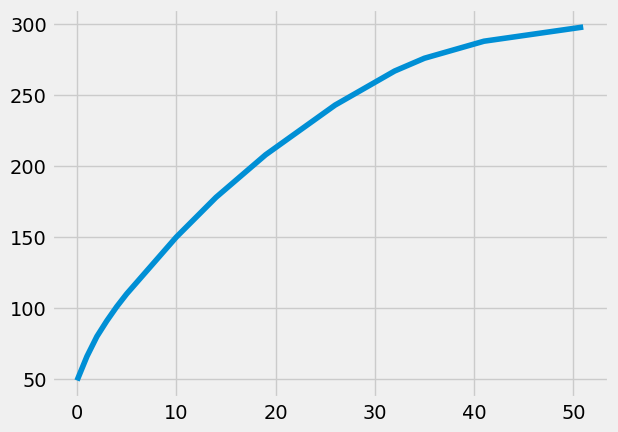

In [57]:
plt.plot(CDPHE_misclassified_counts["Cumulative"])

### TLGRF_FP

In [58]:
TLGRF_FP.describe()

,fips,changepoint,outbreak,capacity,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,cases,deaths,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,num_beds,count_homes,num_inmates,count_facilities,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision
count,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,7.200000e+01,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,0.0,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.00000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.00000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.00000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.0,75.000000,75.000000,75.0,75.000000,75.000000,75.00000,75.0,75.000000,75.000000,75.000000,75.0,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.0
mean,8068.733333,0.133333,0.133333,1.253333,67.840000,626.946667,4.781453,400.355714,0.031708,5.148469,4.999250,5.003410,29.879461,4.824940,4.733672,4.737323,4.608043,0.117700,39.049603,0.055875,5.588016e-02,0.261287,0.165244,0.164347,0.056437,0.036495,0.036377,NaN,198.373333,32.840000,183.723810,38.537026,-106.114713,1967.615501,27941.00000,14559.973333,10768.960000,2532.026667,636.106667,33276.493333,1386.146667,4284.426667,5733.146667,2698.586667,621.560000,6629.693333,492.120000,1731.573333,1436.906667,287.613333,355.733333,784.893333,11.338667,2.229333,4.872000,1.520000,33276.493333,2606.440000,8.64000,1.682667,16.128000,0.385333,20.609333,0.353333,11.773333,1.512000,6.370667,1.852000,25.212,0.468000,2.154667,0.928000,8.646667,1.406667,10.393333,1.740000,2.674667,1.270667,4.225333,1.497333,4.190667,1.23600,0.290084,0.378437,0.307119,0.266831,1.242471,0.286211,0.335917,0.351517,0.252984,0.271755,1.212173,0.226077,0.607904,0.587247,1.195151,0.622561,0.624553,0.453600,0.601260,0.270072,0.482296,2.431781,0.515451,6.081576,0.339277,0.026667,0.040000,0.066667,0

In [59]:
TLGRF_FP[["fips","county_x"]].value_counts()

fips  county_x  
8067  La Plata      17
8039  Elbert         7
8071  Las Animas     4
8109  Saguache       4
8103  Rio Blanco     4
                    ..
8045  Garfield       1
8029  Delta          1
8025  Crowley        1
8015  Chaffee        1
8073  Lincoln        1
Length: 28, dtype: int64

In [60]:
TLGRF_FN = beds_filtered_CDPHE_w_TLGRF_merged[beds_filtered_CDPHE_w_TLGRF_merged["TLGRF_FN"]==1]
TLGRF_FN.describe()

,fips,changepoint,outbreak,capacity,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,cases,deaths,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,num_beds,count_homes,num_inmates,count_facilities,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision
count,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,6.800000e+01,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,0.0,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.00000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.00000,75.000000,75.00000,75.00000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.00000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.0,75.0000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.0,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.0
mean,8064.840000,0.133333,0.133333,1.253333,46.760000,626.946667,4.319306,593.139509,0.018303,4.529616,4.437895,4.447427,5.258377,4.456135,4.403797,4.407534,4.337017,0.113280,10.228992,5.932290e-02,0.056013,0.243937,0.183342,0.177638,0.059403,0.044877,0.043556,NaN,115.000000,27.173333,103.933333,38.363752,-106.190891,1996.425912,23457.026667,12910.253333,9110.173333,2362.773333,566.440000,32469.92000,1238.800000,3862.560000,4628.813333,2442.626667,556.493333,5695.706667,373.080000,1411.013333,1311.706667,239.440000,346.173333,984.306667,12.553333,2.514667,5.37200,1.741333,32469.92000,2806.00000,8.346667,1.746667,17.468000,0.396000,19.622667,0.438667,12.846667,1.676000,6.797333,2.126667,25.77200,0.640000,1.742667,0.929333,8.472000,1.526667,10.553333,1.869333,2.472000,1.248000,4.600000,1.581333,5.148000,1.496000,0.346745,0.426172,0.349284,0.255400,1.377601,0.322675,0.431048,0.280592,0.344763,0.318324,1.374727,0.281509,0.610940,0.593055,1.203995,0.628304,0.632059,0.464457,0.570020,0.324373,0.518899,2.509808,0.530020,6.466131,0.375816,0.040000,0.093333,0

In [61]:
TLGRF_FN[["fips","county_x"]].value_counts()

fips  county_x  
8067  La Plata      12
8097  Pitkin         7
8071  Las Animas     7
8103  Rio Blanco     3
8083  Montezuma      3
                    ..
8081  Moffat         1
8073  Lincoln        1
8055  Huerfano       1
8033  Dolores        1
8125  Yuma           1
Length: 30, dtype: int64

In [62]:
TLGRF_misclassified = beds_filtered_CDPHE_w_TLGRF_merged[(beds_filtered_CDPHE_w_TLGRF_merged["TLGRF_FP"] == 1)|(beds_filtered_CDPHE_w_TLGRF_merged["TLGRF_FN"] == 1)]
TLGRF_misclassified.describe()

,fips,changepoint,outbreak,capacity,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,cases,deaths,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,num_beds,count_homes,num_inmates,count_facilities,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,1.400000e+02,1.400000e+02,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,0.0,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.00000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.0,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.0,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,8066.786667,0.133333,0.133333,1.253333,57.300000,626.946667,4.550379,496.747611,0.025006,4.839043,4.718573,4.725418,17.568919,4.645806,4.573447,4.577140,4.476402,0.115553,25.051020,5.754969e-02,5.594476e-02,0.252860,0.174034,0.170803,0.057878,0.040567,0.039864,NaN,156.686667,30.006667,143.828571,38.450389,-106.152802,1982.020706,25699.013333,13735.113333,9939.566667,2447.400000,601.273333,32873.206667,1312.473333,4073.493333,5180.980000,2570.606667,589.026667,6162.700000,432.600000,1571.293333,1374.306667,263.526667,350.953333,884.600000,11.946000,2.372000,5.122000,1.630667,32873.206667,2706.220000,8.493333,1.714667,16.79800,0.390667,20.116000,0.396000,12.310000,1.594000,6.584000,1.989333,25.492000,0.554000,1.948667,0.928667,8.559333,1.466667,10.473333,1.804667,2.573333,1.259333,4.412667,1.539333,4.669333,1.366000,0.318415,0.402305,0.328201,0.261115,1.310036,0.304443,0.383483,0.316055,0.298873,0

In [63]:
TLGRF_misclassified_counts = pd.DataFrame(TLGRF_misclassified[["fips","county_x"]].value_counts())
TLGRF_misclassified_counts = TLGRF_misclassified_counts.rename(columns={0:"# Times Misclassified"})
TLGRF_misclassified_counts["Cumulative"] = TLGRF_misclassified_counts["# Times Misclassified"].cumsum()
TLGRF_misclassified_counts["Cumulative Percentage"] = 100*TLGRF_misclassified_counts["Cumulative"] / TLGRF_misclassified_counts["Cumulative"].max()

TLGRF_misclassified_counts = TLGRF_misclassified_counts.reset_index()
TLGRF_misclassified_counts

,fips,county_x,# Times Misclassified,Cumulative,Cumulative Percentage
0,8067,La Plata,29,29,19.333333
1,8071,Las Animas,11,40,26.666667
2,8097,Pitkin,10,50,33.333333
3,8039,Elbert,10,60,40.000000
4,8103,Rio Blanco,7,67,44.666667
...,...,...,...,...,...
31,8099,Prowers,1,146,97.333333
32,8033,Dolores,1,147,98.000000
33,8029,Delta,1,148,98.666667
34,8121,Washington,1,149,99.333333


Text(0.5, 1.0, 'Cumulative % of Total Misclassifications against Number of Unique Misclassified Counties')

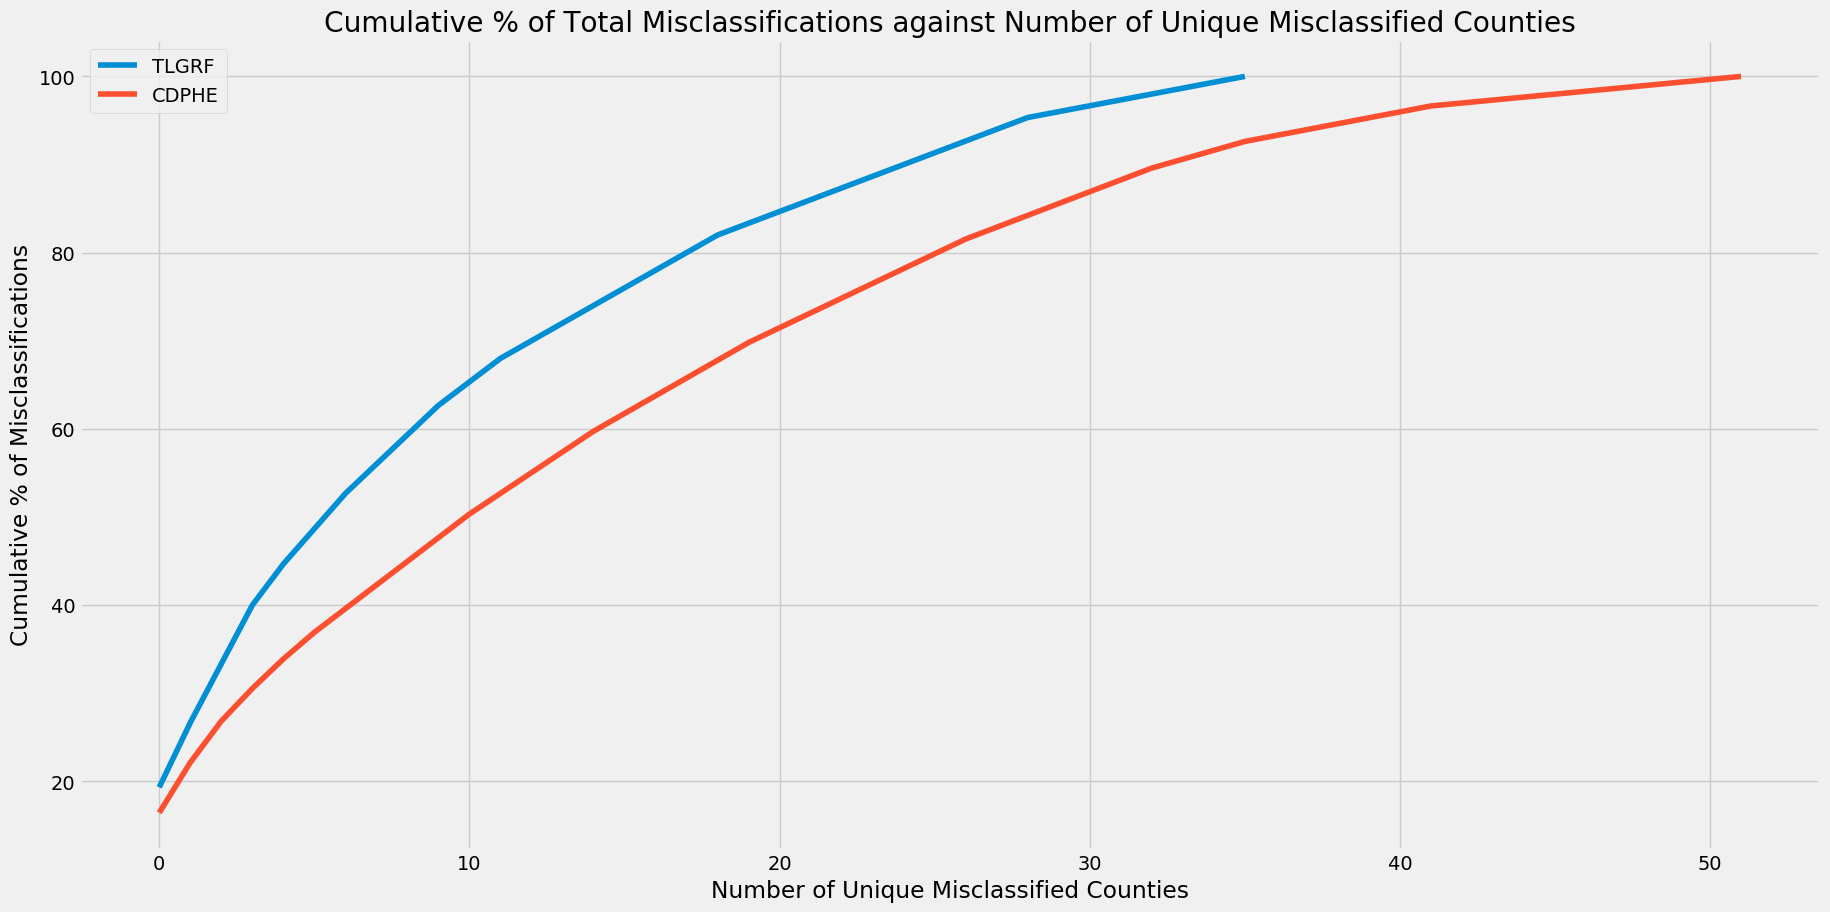

In [64]:
plt.figure(figsize=(20,10))
plt.plot(TLGRF_misclassified_counts["Cumulative Percentage"], label="TLGRF")
plt.plot(CDPHE_misclassified_counts["Cumulative Percentage"], label="CDPHE")
plt.legend()
plt.xlabel("Number of Unique Misclassified Counties")
plt.ylabel("Cumulative % of Misclassifications")
plt.title("Cumulative % of Total Misclassifications against Number of Unique Misclassified Counties")

Text(0.5, 1.0, 'Cumulative # of Total Misclassifications against Number of Unique Misclassified Counties')

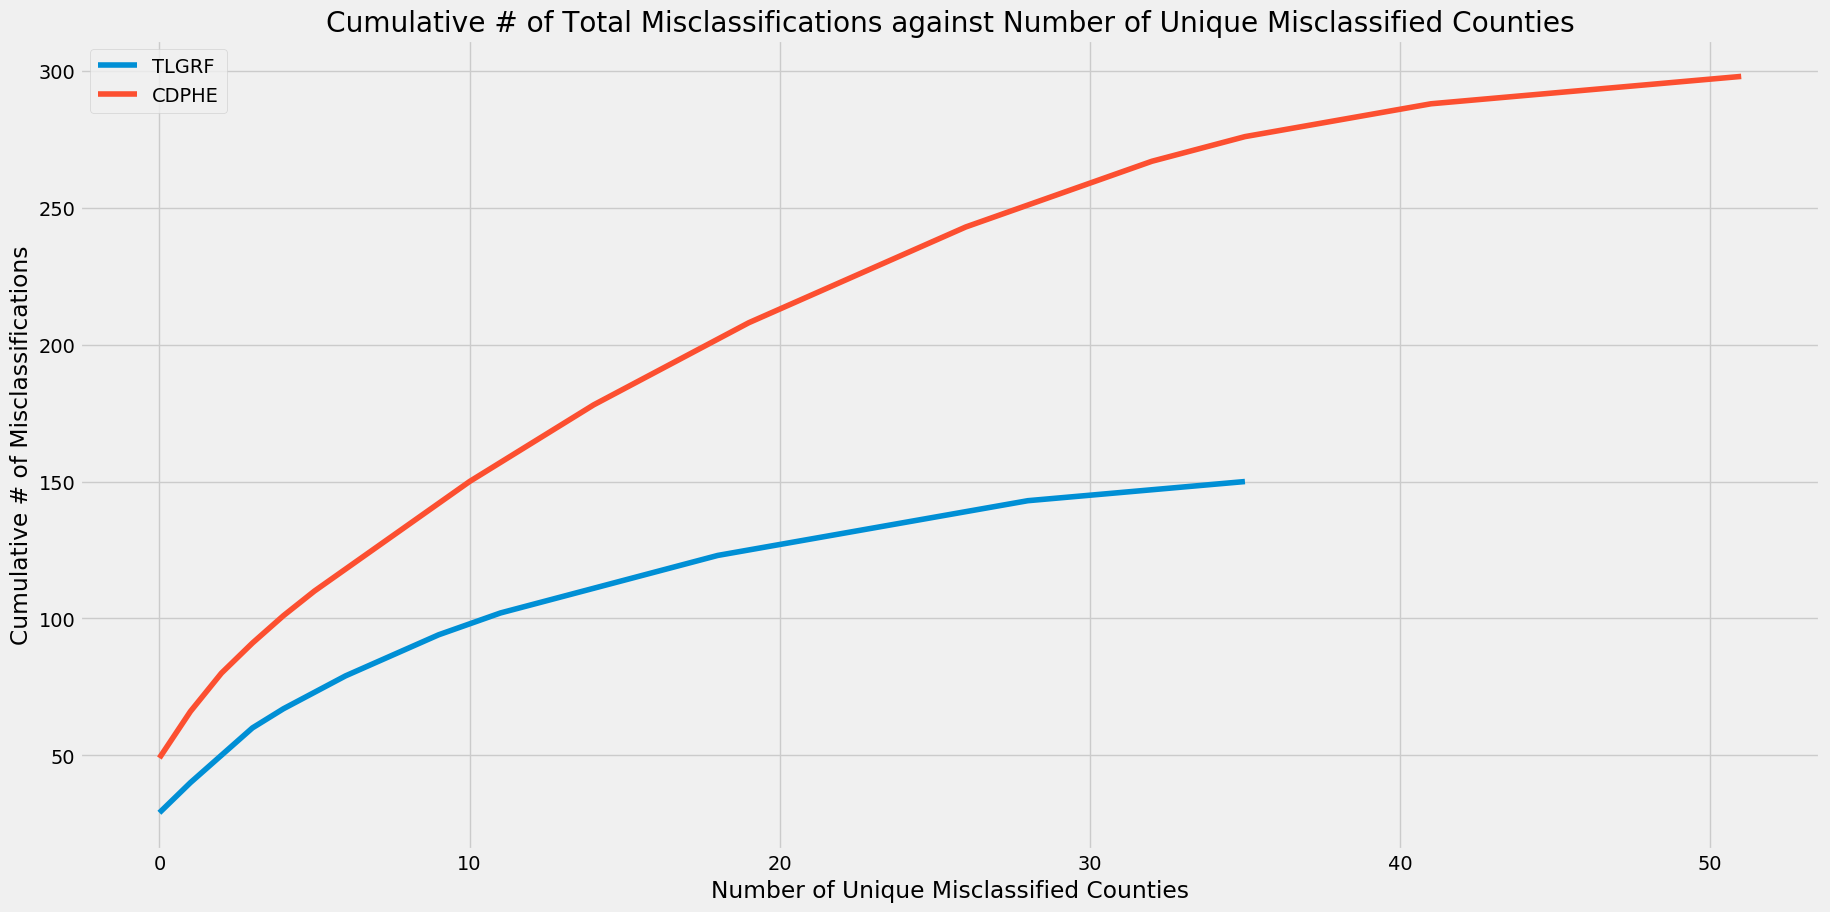

In [65]:
plt.figure(figsize=(20,10))
plt.plot(TLGRF_misclassified_counts["Cumulative"], label="TLGRF")
plt.plot(CDPHE_misclassified_counts["Cumulative"], label="CDPHE")
plt.legend()
plt.xlabel("Number of Unique Misclassified Counties")
plt.ylabel("Cumulative # of Misclassifications")
plt.title("Cumulative # of Total Misclassifications against Number of Unique Misclassified Counties")

### Compare Top 10 Most Misclassified Counties with Everything

In [66]:
display(CDPHE_misclassified_counts.head(10))

,fips,county_x,# Times Misclassified,Cumulative,Cumulative Percentage
0,8067,La Plata,49,49,16.442953
1,8097,Pitkin,17,66,22.147651
2,8039,Elbert,14,80,26.845638
3,8007,Archuleta,11,91,30.536913
4,8021,Conejos,10,101,33.892617
5,8083,Montezuma,9,110,36.912752
6,8051,Gunnison,8,118,39.597315
7,8071,Las Animas,8,126,42.281879
8,8029,Delta,8,134,44.966443
9,8025,Crowley,8,142,47.651007


In [67]:
display(TLGRF_misclassified_counts.head(10))

,fips,county_x,# Times Misclassified,Cumulative,Cumulative Percentage
0,8067,La Plata,29,29,19.333333
1,8071,Las Animas,11,40,26.666667
2,8097,Pitkin,10,50,33.333333
3,8039,Elbert,10,60,40.000000
4,8103,Rio Blanco,7,67,44.666667
5,8113,San Miguel,6,73,48.666667
6,8063,Kit Carson,6,79,52.666667
7,8051,Gunnison,5,84,56.000000
8,8037,Eagle,5,89,59.333333
9,8083,Montezuma,5,94,62.666667


In [68]:
CDPHE_w_TLGRF_merged["fips"].unique()

array([8001, 8003, 8005, 8007, 8009, 8011, 8013, 8014, 8015, 8017, 8019,
       8021, 8023, 8025, 8027, 8029, 8031, 8033, 8035, 8037, 8039, 8041,
       8043, 8045, 8047, 8049, 8051, 8053, 8055, 8057, 8059, 8061, 8063,
       8065, 8067, 8069, 8071, 8073, 8075, 8077, 8079, 8081, 8083, 8085,
       8087, 8089, 8091, 8093, 8095, 8097, 8099, 8101, 8103, 8105, 8107,
       8109, 8111, 8113, 8115, 8117, 8119, 8121, 8123, 8125])

### "Census Data" + Nurse + Correctional Facilities

In [69]:
beds_filtered_CDPHE_w_TLGRF_merged["fips"].unique()


LAT_loc = beds_filtered_CDPHE_w_TLGRF_merged.columns.get_loc("LAT")
log_rolled_cases_loc = beds_filtered_CDPHE_w_TLGRF_merged.columns.get_loc("log_rolled_cases")

cols_to_keep = ["fips", "county_x"] + list(beds_filtered_CDPHE_w_TLGRF_merged.columns[LAT_loc:log_rolled_cases_loc])
overall_census_data = beds_filtered_CDPHE_w_TLGRF_merged[cols_to_keep].drop_duplicates(keep="first")
#overall_census_data = pd.merge(overall_census_data, beds_and_inmates_per_county_df, on="fips", how="inner")
overall_census_data

,fips,county_x,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,num_beds,count_homes,num_inmates,count_facilities
0,8003,Alamosa,37.568442,-105.788041,722.576715,16444.0,6936.0,6153.0,3635.0,708.0,21328.0,1287.0,2113.0,3932.0,2948.0,387.0,8504.0,640.0,451.0,1113.0,196.0,506.0,1089.0,23.7,4.1,9.3,3.3,21328.0,1792.0,13.5,2.5,12.8,0.2,23.9,0.3,18.4,2.0,6.3,2.2,51.7,0.3,4.2,1.7,6.5,2.1,16.0,2.4,3.2,1.7,8.2,2.9,6.6,1.5,0.8911,0.9121,0.8417,0.5772,3.2221,0.8669,0.0952,0.7122,0.7358,0.2069,1.7501,0.2958,0.8863,0.8968,1.7831,0.9331,0.7771,0.6778,0.7953,0.8026,0.8650,3.9178,0.9943,10.6731,0.9452,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2237.0,14.0,3.0,16662.0,123.0,2.0,0.0,0.0
20,8007,Archuleta,37.202395,-107.050863,1350.086257,12908.0,9228.0,5670.0,1370.0,358.0,31035.0,781.0,3168.0,2209.0,1856.0,195.0,3018.0,118.0,300.0,1048.0,225.0,65.0,164.0,10.7,2.8,5.8,2.5,31035.0,2612.0,8.0,1.8,24.5,0.4,17.1,0.3,14.5,2.0,3.4,1.3,23.4,0.2,1.0,0.9,3.3,1.3,11.4,2.1,4.0,2.1,1.1,0.9,1.3,0.3,0.2312,0.5481,0.2102,0.1971,1.1866,0.2608,0.9064,0.0560,0.4075,0.0242,1.3941,0.1251,0.6145,0.5791,1.1936,0.6224,0.5450,0.5189,0.8787,0.0115,0.2582,2.2123,0.3413,5.9866,0.2570,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1421.0,11.1,2.2,10352.0,0.0,0.0,0.0,0.0
64,8009,Baca,37.309780,-102.543741,2554.991586,3563.0,2254.0,1642.0,661.0,41.0,23862.0,398.0,923.0,739.0,729.0,103.0,525.0,89.0,34.0,257.0,25.0,100.0,96.0,19.2,3.3,2.5,1.1,23862.0,1836.0,15.2,2.7,25.9,0.7,20.7,0.2,21.1,2.7,6.3,2.2,14.7,0.3,2.6,1.9,1.5,0.9,11.4,2.7,1.5,1.3,6.1,2.1,2.7,2.2,0.7545,0.0777,0.6723,0.6660,2.1705,0.5634,0.9379,0.2846,0.8679,0.2069,2.2973,0.7291,0.4645,0.8192,1.2837,0.6800,0.2798,0.5189,0.3359,0.5626,0.6250,2.3222,0.3941,8.0737,0.6086,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,234.0,6.8,1.9,2480.0,0.0,0.0,0.0,0.0
76,8011,Bent,37.931891,-103.077584,1512.846146,5809.0,2258.0,1744.0,912.0,119.0,14777.0,646.0,1005.0,894.0,1013.0,176.0,2127.0,121.0,13.0,298.0,35.0,167.0,1873.0,22.9,4.9,7.2,3.4,14777.0,1766.0,14.2,2.6,17.3,0.7,15.4,0.0,25.4,3.2,10.1,4.2,36.6,1.3,2.2,1.3,0.6,0.6,13.2,3.1,2.0,2.3,9.6,3.3,32.2,4.8,0.8729,0.7583,0.9914,0.6129,3.2355,0.8701,0.4190,0.0201,0.9723,0.7771,2.1885,0.6457,0.7657,0.7848,1.5505,0.8313,0.1035,0.5928,0.5180,0.8892,0.9959,3.0994,0.8077,10.0739,0.8981,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,3.0,379.0,9.5,3.0,5033.0,56.0,1.0,0.0,0.0
107,8013,Boulder,40.094970,-105.397691,726.369908,321030.0,134326.0,125894.0,38546.0,8716.0,43831.0,10380.0,42068.0,62925.0,25747.0,8338.0,71227.0,5927.0,23720.0,3962.0,2080.0,6707.0,11616.0,12.5,0.6,4.8,0.3,43831.0,833.0,4.9,0.3,13.1,0.1,19.6,0.0,8.1,0.4,6.6,0.5,22.2,0.1,1.9,0.2,17.7,0.7,2.9,0.3,1.7,0.2,5.3,0.4,3.6,0.2,0.3430,0.3838,0.0207,0.0334,0.7809,0.1334,0.1079,0.1853,0.0169,0.2385,0.5486,0.0111,0.5934,0.7491,1.3425,0.7157,0.9675,0.1152,0.4056,0.4225,0.7262,2.6370,0.5673,5.3090,0.1704,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,16064.0,5.0,0.3,321368.0,1078.0,11.0,0.0,0.0
...,...,...,...,...,...,...,...,

In [70]:
CDPHE_misclassified_census = overall_census_data[overall_census_data["fips"].isin(CDPHE_misclassified_counts.head(10)["fips"])]
CDPHE_misclassified_census

,fips,county_x,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,num_beds,count_homes,num_inmates,count_facilities
20,8007,Archuleta,37.202395,-107.050863,1350.086257,12908.0,9228.0,5670.0,1370.0,358.0,31035.0,781.0,3168.0,2209.0,1856.0,195.0,3018.0,118.0,300.0,1048.0,225.0,65.0,164.0,10.7,2.8,5.8,2.5,31035.0,2612.0,8.0,1.8,24.5,0.4,17.1,0.3,14.5,2.0,3.4,1.3,23.4,0.2,1.0,0.9,3.3,1.3,11.4,2.1,4.0,2.1,1.1,0.9,1.3,0.3,0.2312,0.5481,0.2102,0.1971,1.1866,0.2608,0.9064,0.0560,0.4075,0.0242,1.3941,0.1251,0.6145,0.5791,1.1936,0.6224,0.5450,0.5189,0.8787,0.0115,0.2582,2.2123,0.3413,5.9866,0.2570,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1421.0,11.1,2.2,10352.0,0.0,0.0,0.0,0.0
296,8021,Conejos,37.213406,-106.176447,1287.436098,8142.0,4398.0,3068.0,1813.0,374.0,19545.0,711.0,1466.0,2210.0,1607.0,256.0,4558.0,203.0,88.0,813.0,114.0,195.0,62.0,22.4,3.6,11.5,3.0,19545.0,1374.0,13.4,2.1,18.0,0.2,27.1,0.1,19.8,1.9,8.3,2.1,56.0,0.3,2.7,1.1,2.0,1.0,18.5,2.5,3.7,1.5,6.4,1.7,0.8,0.4,0.8627,0.9637,0.9188,0.5715,3.3167,0.8879,0.4893,0.9265,0.8169,0.5234,2.7561,0.9405,0.9077,0.8274,1.7351,0.9175,0.3725,0.7440,0.8551,0.6043,0.0936,2.6695,0.5903,10.4774,0.9325,0.0,1.0,1.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1091.0,13.5,3.1,5853.0,0.0,0.0,0.0,0.0
373,8025,Crowley,38.306180,-103.772736,787.427181,5630.0,1584.0,1194.0,1261.0,349.0,14988.0,590.0,724.0,717.0,958.0,107.0,2113.0,141.0,25.0,283.0,35.0,64.0,1184.0,28.4,6.5,16.1,5.9,14988.0,2363.0,15.2,3.7,12.9,0.6,12.7,0.0,21.6,3.6,9.0,3.6,37.5,1.4,2.6,1.5,1.6,1.2,17.9,5.1,2.9,2.6,5.4,2.2,21.0,8.6,0.9602,0.9920,0.9901,0.6660,3.6083,0.9519,0.0990,0.0038,0.8886,0.6399,1.6313,0.2315,0.7752,0.8192,1.5944,0.8507,0.2980,0.7287,0.7434,0.4435,0.9857,3.1993,0.8478,10.0333,0.8930,1.0,1.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,4.0,308.0,7.0,2.7,4284.0,37.0,1.0,1681.0,1.0
428,8029,Delta,38.861595,-107.864892,1142.126464,30346.0,14763.0,11882.0,5145.0,1010.0,24886.0,2130.0,7499.0,6176.0,5478.0,571.0,5637.0,477.0,282.0,2348.0,274.0,595.0,1259.0,17.6,2.6,8.5,2.2,24886.0,1562.0,9.6,1.3,24.7,0.3,20.4,0.3,18.8,1.5,4.8,1.2,18.6,0.1,1.7,0.6,1.9,0.8,15.9,2.2,2.3,0.9,5.0,1.3,4.1,0.8,0.6860,0.8675,0.5946,0.3114,2.4595,0.6554,0.9128,0.2550,0.7638,0.0735,2.0051,0.4900,0.5450,0.7170,1.2620,0.6644,0.3582,0.6746,0.6049,0.3715,0.7635,2.7727,0.6466,8.4993,0.6866,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2981.0,10.2,1.4,25386.0,185.0,3.0,0.0,0.0
513,8039,Elbert,39.315157,-104.114076,1850.835533,25162.0,9459.0,9046.0,1110.0,380.0,43349.0,595.0,3689.0,5514.0,2506.0,340.0,2788.0,32.0,57.0,388.0,126.0,180.0,68.0,4.4,0.9,2.7,0.7,43349.0,1943.0,3.3,0.8,14.7,0.3,21.9,0.1,10.0,1.1,3.8,1.1,11.1,0.1,0.1,0.4,0.6,0.5,4.1,1.1,1.4,0.6,2.0,0.8,0.3,0.1,0.0045,0.0949,0.0242,0.0064,0.1300,0.0019,0.1917,0.4323,0.0646,0.0328,0.7214,0.0197,0.3766,0.0707,0.4473,0.2025,0.1035,0.1808,0.2964,0.0322,0.0255,0.6384,0.0035,1.9371,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1451.0,5.8,1.5,12940.0,0.0,0.0,0.0,0.0
698,8051,Gunnison,38.670499,-107.056880,3

In [71]:
TLGRF_misclassified_census = overall_census_data[overall_census_data["fips"].isin(TLGRF_misclassified_counts.head(10)["fips"])]
TLGRF_misclassified_census

,fips,county_x,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,num_beds,count_homes,num_inmates,count_facilities
479,8037,Eagle,39.626992,-106.695169,1684.470957,54357.0,32154.0,17750.0,3793.0,764.0,41064.0,4075.0,5482.0,12118.0,2332.0,1015.0,17856.0,3473.0,8466.0,1724.0,768.0,304.0,84.0,7.0,1.6,2.2,0.8,41064.0,2404.0,10.7,1.4,10.1,0.3,22.3,0.1,4.3,0.9,5.7,1.4,32.8,0.0,6.8,1.0,26.3,1.8,5.4,1.0,4.3,1.3,1.7,0.9,0.2,0.2,0.0497,0.0573,0.0331,0.3996,0.5397,0.0662,0.0207,0.4906,0.0003,0.1391,0.6507,0.0156,0.7221,0.9487,1.6708,0.8886,0.9898,0.2518,0.8911,0.0232,0.0204,2.1763,0.3260,5.0375,0.1369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,8190.0,15.1,1.9,52146.0,0.0,0.0,0.0,0.0
513,8039,Elbert,39.315157,-104.114076,1850.835533,25162.0,9459.0,9046.0,1110.0,380.0,43349.0,595.0,3689.0,5514.0,2506.0,340.0,2788.0,32.0,57.0,388.0,126.0,180.0,68.0,4.4,0.9,2.7,0.7,43349.0,1943.0,3.3,0.8,14.7,0.3,21.9,0.1,10.0,1.1,3.8,1.1,11.1,0.1,0.1,0.4,0.6,0.5,4.1,1.1,1.4,0.6,2.0,0.8,0.3,0.1,0.0045,0.0949,0.0242,0.0064,0.1300,0.0019,0.1917,0.4323,0.0646,0.0328,0.7214,0.0197,0.3766,0.0707,0.4473,0.2025,0.1035,0.1808,0.2964,0.0322,0.0255,0.6384,0.0035,1.9371,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1451.0,5.8,1.5,12940.0,0.0,0.0,0.0,0.0
698,8051,Gunnison,38.670499,-107.056880,3239.140212,16537.0,11854.0,6643.0,2084.0,589.0,30127.0,296.0,2044.0,2929.0,1294.0,511.0,2119.0,71.0,1120.0,673.0,132.0,197.0,896.0,13.2,3.0,5.8,1.6,30127.0,1499.0,2.8,1.1,12.4,0.3,17.7,0.5,7.8,1.4,7.7,2.2,12.8,0.2,0.4,0.6,9.4,1.7,5.7,1.2,2.0,1.0,3.0,1.6,5.4,0.7,0.3908,0.5481,0.2494,0.0035,1.1918,0.2631,0.0780,0.0735,0.0140,0.4126,0.5781,0.0127,0.4193,0.2970,0.7163,0.3426,0.8685,0.2668,0.5180,0.0920,0.8262,2.5715,0.5326,5.0577,0.1392,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1779.0,10.8,2.3,15340.0,0.0,0.0,0.0,0.0
793,8063,Kit Carson,39.305340,-102.603023,2160.820615,7635.0,3548.0,2977.0,705.0,184.0,27471.0,622.0,1378.0,1791.0,989.0,288.0,1783.0,284.0,104.0,472.0,22.0,128.0,641.0,10.1,3.2,4.9,1.9,27471.0,6090.0,11.5,2.6,18.0,0.4,23.5,0.7,14.1,1.9,9.7,3.1,23.4,0.1,3.9,1.9,2.9,1.6,13.3,2.8,0.7,0.6,4.3,2.3,8.4,5.1,0.1949,0.3981,0.4089,0.4562,1.4581,0.3373,0.4893,0.6581,0.3629,0.7316,2.2419,0.6902,0.6145,0.8857,1.5002,0.8058,0.4947,0.5957,0.0780,0.2563,0.9077,2.3324,0.4015,7.5326,0.5153,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,886.0,12.6,4.6,5404.0,0.0,0.0,0.0,0.0
958,8067,La Plata,37.287367,-107.839718,1689.783902,55101.0,27442.0,21793.0,4609.0,1250.0,37864.0,1966.0,8634.0,10565.0,4854.0,1065.0,11719.0,275.0,2280.0,3647.0,533.0,571.0,1888.0,8.7,1.0,4.1,0.8,37864.0,2105.0,5.0,0.7,15.7,0.1,19.2,0.0,8.9,0.8,4.9,0.8,21.3,0.1,0.5,0.3,8.3,1.2,13.3,1.3,2.4,0.8,2.6,0.6,3.4,0.6,0.1166,0.2611,0.0596,0.0357,0.4730,0.0503,0.2665,0.1506,0.0296,0.0777,0.5244,0.0102,0.5817,0.3582,0.9399,0.4801,0.8399,0.5957,0.6313,0.0630,0.7103,2.8402,0.6829,4.7775,0.1086,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4993.0,9.1,1.2,53142.0,0.0,0.0,0.0,0.0
1109,8071,Las Animas,37.318831,-10

In [72]:
col_of_interest = ["E_TOTPOP", "E_POV", "E_UNEMP", "E_AGE65", "E_AGE17", "E_DISABL", "E_UNINSUR", "num_beds", "num_inmates"]

In [73]:
CDPHE_vs_all_ttest = t_test_results(CDPHE_misclassified, beds_filtered_CDPHE_w_TLGRF_merged[beds_filtered_CDPHE_w_TLGRF_merged["P"]==1], start_loc=LAT_loc, end_loc=log_rolled_cases_loc)
CDPHE_vs_all_ttest[CDPHE_vs_all_ttest["Column"].isin(col_of_interest)].T

,3,6,7,10,11,12,94,98,100
Column,E_TOTPOP,E_POV,E_UNEMP,E_AGE65,E_AGE17,E_DISABL,E_UNINSUR,num_beds,num_inmates
t-statistic,-1.125312,-1.242205,-1.23438,-1.105944,-1.076304,-1.108548,-1.577232,-0.363883,-0.259158
p-value,0.261022,0.21477,0.217668,0.269307,0.282334,0.268183,0.115404,0.716106,0.795625
Standard Error,7181.763155,875.631974,168.453195,879.97982,1554.736955,697.938301,664.031674,24.559347,111.792486
Confidence Interval,"(-21900.562186337324, 6251.94938303325)","(-2713.1055837575022, 719.3717538290409)","(-528.6076757114056, 131.72884983929094)","(-2701.6091446763417, 747.9117481131739)","(-4665.779342333033, 1428.7895200747548)","(-2111.489529545098, 624.4286105982728)","(-2262.677610863905, 340.32655252626955)","(-57.00349250490502, 39.269146314183)","(-247.31347243436744, 190.91307417490884)"


In [74]:
TLGRF_vs_all_ttest = t_test_results(TLGRF_misclassified, beds_filtered_CDPHE_w_TLGRF_merged[beds_filtered_CDPHE_w_TLGRF_merged["P"]==1], start_loc=LAT_loc, end_loc=log_rolled_cases_loc)
TLGRF_vs_all_ttest[CDPHE_vs_all_ttest["Column"].isin(col_of_interest)].T

,3,6,7,10,11,12,94,98,100
Column,E_TOTPOP,E_POV,E_UNEMP,E_AGE65,E_AGE17,E_DISABL,E_UNINSUR,num_beds,num_inmates
t-statistic,-2.633531,-2.472675,-2.743253,-3.037361,-2.640621,-2.768251,-2.438093,-2.144327,-0.993778
p-value,0.008848,0.013914,0.006416,0.002577,0.008669,0.005954,0.015292,0.032737,0.321059
Standard Error,6139.13349,782.045769,145.647777,727.61242,1327.665752,598.23909,611.527715,20.525059,120.618693
Confidence Interval,"(-29653.380614653062, -5587.977334064883)","(-3654.283332658856, -588.6639200883967)","(-721.894111925364, -150.95482580357395)","(-3820.6434935148063, -968.4028068514936)","(-6425.90421456593, -1221.4544667527512)","(-2981.365025711818, -636.2677948010032)","(-2818.1599617861893, -420.9713202650926)","(-88.0191512944177, -7.560921965655574)","(-359.179012156074, 113.64626490332682)"


In [75]:
CDPHE_vs_TLGRF_ttest = t_test_results(CDPHE_misclassified_census, TLGRF_misclassified_census, start_loc=2, end_loc=-1)
CDPHE_vs_TLGRF_ttest[CDPHE_vs_TLGRF_ttest["Column"].isin(col_of_interest)].T

,3,6,7,10,11,12,90,94,96
Column,E_TOTPOP,E_POV,E_UNEMP,E_AGE65,E_AGE17,E_DISABL,E_UNINSUR,num_beds,num_inmates
t-statistic,-0.26725,0.539859,0.59325,0.364474,-0.378686,0.729037,-0.505326,0.933761,1.0
p-value,0.792314,0.595911,0.560395,0.719751,0.709351,0.475359,0.619461,0.362785,0.330565
Standard Error,7258.734462,682.029639,142.941542,1115.854065,1510.750604,736.725039,876.068012,23.774823,168.1
Confidence Interval,"(-16167.0195464435, 12287.219546443497)","(-968.5780930354731, 1704.9780930354727)","(-195.36542242357064, 364.96542242357054)","(-1780.3739674592111, 2593.7739674592117)","(-3533.171184029035, 2388.9711840290342)","(-906.8810767642813, 1981.081076764281)","(-2159.793302917592, 1274.3933029175917)","(-24.398653638156638, 68.79865363815665)","(-161.376, 497.576)"


In [76]:
CDPHE_misclassified_summary = CDPHE_misclassified[col_of_interest].describe().replace("50%","median")
TLGRF_misclassified_summary = TLGRF_misclassified[col_of_interest].describe().replace("50%","median")
overall_misclassified_summary = (beds_filtered_CDPHE_w_TLGRF_merged[beds_filtered_CDPHE_w_TLGRF_merged["P"]==1][col_of_interest]).describe().replace("50%","median")

In [77]:
overall_misclassified_summary

,E_TOTPOP,E_POV,E_UNEMP,E_AGE65,E_AGE17,E_DISABL,E_UNINSUR,num_beds,num_inmates
count,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000
mean,43319.692308,4568.873626,1037.697802,6468.016484,9004.659341,4379.423077,4226.192308,78.296703,286.126374
std,79999.145219,10408.944188,1911.633862,9298.923078,17341.014273,7850.446812,7882.161473,264.210196,1236.256352
min,1841.000000,250.000000,9.000000,471.000000,356.000000,411.000000,93.000000,0.000000,0.000000
25%,13060.000000,1289.000000,374.000000,2423.000000,2547.000000,1294.000000,1263.000000,0.000000,0.000000
50%,25162.000000,3075.000000,589.000000,3689.000000,5514.000000,2939.000000,2395.000000,0.000000,0.000000
75%,55101.000000,4609.000000,1250.000000,8634.000000,10565.000000,4854.000000,4993.000000,0.000000,0.000000
max,693417.000000,93728.000000,16235.000000,78751.000000,139801.000000,66458.000000,70752.000000,2203.000000,8037.000000


In [78]:
stats_to_drop = ["count","std","min","max","25%","75%"]

CDPHE_selected = CDPHE_misclassified_summary.drop(stats_to_drop).replace("50%","median")
TLGRF_selected = TLGRF_misclassified_summary.drop(stats_to_drop).replace("50%","median")
overall_selected = overall_misclassified_summary.drop(stats_to_drop).replace("50%","median")



comparison_df = pd.concat([CDPHE_selected, TLGRF_selected, overall_selected], keys=['CDPHE Misclassified Counties', 'TLGRF Misclassified Counties', 'Overall'])
comparison_df.index = comparison_df.index.set_names(['Counties of:', 'Statistics'])

comparison_df

E_TOTPOP        E_POV  \
Counties of:                 Statistics                              
CDPHE Misclassified Counties mean        35495.385906  3572.006711   
                             50%         18325.000000  2084.000000   
TLGRF Misclassified Counties mean        25699.013333  2447.400000   
                             50%         17909.000000  1890.000000   
Overall                      mean        43319.692308  4568.873626   
                             50%         25162.000000  3075.000000   

                                             E_UNEMP      E_AGE65  \
Counties of:                 Statistics                             
CDPHE Misclassified Counties mean         839.258389  5491.167785   
                             50%          531.000000  3459.000000   
TLGRF Misclassified Counties mean         601.273333  4073.493333   
                             50%          500.000000  3253.000000   
Overall                      mean        1037.697802  6468.016484   
                             50%          589.000000  3689.000000   

                                             E_AGE17     E_DISABL  \
Counties of:                 Statistics                             
CDPHE Misclassified Counties mean        7386.164430  3635.892617   
                             50%         3381.000000  2332.000000   
TLGRF Misclassified Counties mean        5180.980000  2570.606667   
                             50%         2954.000000  2332.000000   
Overall                      mean        9004.659341  4379.423077   
                             50%         5514.000000  2939.000000   

                                           E_UNINSUR   num_beds  num_inmates  
Counties of:                 Statistics                                       
CDPHE Misclassified Counties mean        3265.016779  69.429530   257.926174  
                             50%         1864.000000   0.000000     0.000000  
TLGRF Misclassified Counties mean        2606.626667  30.506667   163.360000  
                             50%         1762.000000   0.000000     0.000000  
Overall                      mean        4226.192308  78.296703   286.126374  
                             50%         2395.000000   0.000000     0.000000

In [79]:
comparison_df.to_latex(multirow=True, multicolumn=True)

'\\begin{tabular}{llrrrrrrrrr}\n\\toprule\n        &     &      E\\_TOTPOP &        E\\_POV &      E\\_UNEMP &      E\\_AGE65 &      E\\_AGE17 &     E\\_DISABL &    E\\_UNINSUR &   num\\_beds &  num\\_inmates \\\\\nCounties of: & Statistics &               &              &              &              &              &              &              &            &              \\\\\n\\midrule\n\\multirow{2}{*}{CDPHE Misclassified Counties} & mean &  35495.385906 &  3572.006711 &   839.258389 &  5491.167785 &  7386.164430 &  3635.892617 &  3265.016779 &  69.429530 &   257.926174 \\\\\n        & 50\\% &  18325.000000 &  2084.000000 &   531.000000 &  3459.000000 &  3381.000000 &  2332.000000 &  1864.000000 &   0.000000 &     0.000000 \\\\\n\\cline{1-11}\n\\multirow{2}{*}{TLGRF Misclassified Counties} & mean &  25699.013333 &  2447.400000 &   601.273333 &  4073.493333 &  5180.980000 &  2570.606667 &  2606.626667 &  30.506667 &   163.360000 \\\\\n        & 50\\% &  17909.000000 &  1890.000000 & 

In [80]:
comparison_df

E_TOTPOP        E_POV  \
Counties of:                 Statistics                              
CDPHE Misclassified Counties mean        35495.385906  3572.006711   
                             50%         18325.000000  2084.000000   
TLGRF Misclassified Counties mean        25699.013333  2447.400000   
                             50%         17909.000000  1890.000000   
Overall                      mean        43319.692308  4568.873626   
                             50%         25162.000000  3075.000000   

                                             E_UNEMP      E_AGE65  \
Counties of:                 Statistics                             
CDPHE Misclassified Counties mean         839.258389  5491.167785   
                             50%          531.000000  3459.000000   
TLGRF Misclassified Counties mean         601.273333  4073.493333   
                             50%          500.000000  3253.000000   
Overall                      mean        1037.697802  6468.016484   
                             50%          589.000000  3689.000000   

                                             E_AGE17     E_DISABL  \
Counties of:                 Statistics                             
CDPHE Misclassified Counties mean        7386.164430  3635.892617   
                             50%         3381.000000  2332.000000   
TLGRF Misclassified Counties mean        5180.980000  2570.606667   
                             50%         2954.000000  2332.000000   
Overall                      mean        9004.659341  4379.423077   
                             50%         5514.000000  2939.000000   

                                           E_UNINSUR   num_beds  num_inmates  
Counties of:                 Statistics                                       
CDPHE Misclassified Counties mean        3265.016779  69.429530   257.926174  
                             50%         1864.000000   0.000000     0.000000  
TLGRF Misclassified Counties mean        2606.626667  30.506667   163.360000  
                             50%         1762.000000   0.000000     0.000000  
Overall                      mean        4226.192308  78.296703   286.126374  
                             50%         2395.000000   0.000000     0.000000

### CDPHE TP vs Overall

In [81]:
CDPHE_TP_counts = pd.DataFrame(CDPHE_TP[["fips","county_x"]].value_counts())
CDPHE_TP_counts = CDPHE_TP_counts.rename(columns={0:"# Times TP"})
CDPHE_TP_counts["Cumulative"] = CDPHE_TP_counts["# Times TP"].cumsum()
CDPHE_TP_counts["Cumulative Percentage"] = 100*CDPHE_TP_counts["Cumulative"] / CDPHE_TP_counts["Cumulative"].max()

CDPHE_TP_counts = CDPHE_TP_counts.reset_index()
CDPHE_TP_counts.head(10)

,fips,county_x,# Times TP,Cumulative,Cumulative Percentage
0,8125,Yuma,2,2,6.060606
1,8014,Broomfield,2,4,12.121212
2,8097,Pitkin,2,6,18.181818
3,8043,Fremont,2,8,24.242424
4,8045,Garfield,2,10,30.303030
5,8007,Archuleta,2,12,36.363636
6,8075,Logan,2,14,42.424242
7,8083,Montezuma,2,16,48.484848
8,8081,Moffat,1,17,51.515152
9,8123,Weld,1,18,54.545455


In [82]:
TLGRF_TP_counts = pd.DataFrame(TLGRF_TP[["fips","county_x"]].value_counts())
TLGRF_TP_counts = TLGRF_TP_counts.rename(columns={0:"# Times TP"})
TLGRF_TP_counts["Cumulative"] = TLGRF_TP_counts["# Times TP"].cumsum()
TLGRF_TP_counts["Cumulative Percentage"] = 100*TLGRF_TP_counts["Cumulative"] / TLGRF_TP_counts["Cumulative"].max()

TLGRF_TP_counts = TLGRF_TP_counts.reset_index()
TLGRF_TP_counts.head(10)

,fips,county_x,# Times TP,Cumulative,Cumulative Percentage
0,8067,La Plata,37,37,34.579439
1,8097,Pitkin,7,44,41.121495
2,8039,Elbert,7,51,47.663551
3,8075,Logan,4,55,51.401869
4,8029,Delta,4,59,55.140187
5,8123,Weld,3,62,57.943925
6,8021,Conejos,3,65,60.747664
7,8113,San Miguel,3,68,63.551402
8,8085,Montrose,3,71,66.355140
9,8037,Eagle,3,74,69.158879


In [83]:
CDPHE_TP_summary = CDPHE_TP[col_of_interest[:-2]].head(18).describe().replace("50%","median")
CDPHE_selected_TP = CDPHE_TP_summary.drop(stats_to_drop).replace("50%","median")

TLGRF_TP_summary = TLGRF_TP[col_of_interest[:-2]].head(74).describe().replace("50%","median")
TLGRF_selected_TP = TLGRF_TP_summary.drop(stats_to_drop).replace("50%","median") 

comparison_df_TP = pd.concat([CDPHE_selected_TP, TLGRF_selected_TP, overall_selected[col_of_interest[:-2]]], keys=['CDPHE TP Counties', "TLGRF TP Counties", 'Colorado Counties Overall'])
comparison_df_TP

E_TOTPOP        E_POV      E_UNEMP  \
CDPHE TP Counties         mean  69929.555556  8138.944444  1602.444444   
                          50%   27754.000000  3296.000000   736.000000   
TLGRF TP Counties         mean  58924.472973  6003.810811  1338.837838   
                          50%   55101.000000  4609.000000  1250.000000   
Colorado Counties Overall mean  43319.692308  4568.873626  1037.697802   
                          50%   25162.000000  3075.000000   589.000000   

                                    E_AGE65       E_AGE17     E_DISABL  \
CDPHE TP Counties         mean  9320.055556  14571.111111  7039.055556   
                          50%   5076.000000   5845.000000  2990.000000   
TLGRF TP Counties         mean  8490.648649  11784.905405  5618.540541   
                          50%   8634.000000  10565.000000  4854.000000   
Colorado Counties Overall mean  6468.016484   9004.659341  4379.423077   
                          50%   3689.000000   5514.000000  2939.000000   

                                  E_UNINSUR  
CDPHE TP Counties         mean  7057.055556  
                          50%   2414.500000  
TLGRF TP Counties         mean  5637.729730  
                          50%   4993.000000  
Colorado Counties Overall mean  4226.192308  
                          50%   2395.000000

In [84]:
comparison_df_TP.to_latex(multirow=True, multicolumn=True, float_format="{:0.2f}".format)

'\\begin{tabular}{llrrrrrrr}\n\\toprule\n                          &     &  E\\_TOTPOP &   E\\_POV &  E\\_UNEMP &  E\\_AGE65 &  E\\_AGE17 &  E\\_DISABL &  E\\_UNINSUR \\\\\n\\midrule\n\\multirow{2}{*}{CDPHE TP Counties} & mean &  69929.56 & 8138.94 &  1602.44 &  9320.06 & 14571.11 &   7039.06 &    7057.06 \\\\\n                          & 50\\% &  27754.00 & 3296.00 &   736.00 &  5076.00 &  5845.00 &   2990.00 &    2414.50 \\\\\n\\cline{1-9}\n\\multirow{2}{*}{TLGRF TP Counties} & mean &  58924.47 & 6003.81 &  1338.84 &  8490.65 & 11784.91 &   5618.54 &    5637.73 \\\\\n                          & 50\\% &  55101.00 & 4609.00 &  1250.00 &  8634.00 & 10565.00 &   4854.00 &    4993.00 \\\\\n\\cline{1-9}\n\\multirow{2}{*}{Colorado Counties Overall} & mean &  43319.69 & 4568.87 &  1037.70 &  6468.02 &  9004.66 &   4379.42 &    4226.19 \\\\\n                          & 50\\% &  25162.00 & 3075.00 &   589.00 &  3689.00 &  5514.00 &   2939.00 &    2395.00 \\\\\n\\bottomrule\n\\end{tabular}\n'

### t-test for CDPHE vs TLGRF on Vulnerable Populations with SE and CI

In [85]:
### Import in
restricted_col_of_interest = ["E_TOTPOP", "num_beds", "num_inmates"]
rename_dict = {"E_TOTPOP":"Total Population", "num_beds": "Nursing Home Beds", "num_inmates": "Inmates"}

CDPHE_choices = beds_filtered_CDPHE_w_TLGRF_merged[beds_filtered_CDPHE_w_TLGRF_merged["changepoint"] == 1][restricted_col_of_interest].rename(columns=rename_dict)
TLGRF_choices = beds_filtered_CDPHE_w_TLGRF_merged[beds_filtered_CDPHE_w_TLGRF_merged["TLGRF_decision"] == 1][restricted_col_of_interest].rename(columns=rename_dict)

In [86]:
CDPHE_vs_TLGRF_means = pd.DataFrame()
CDPHE_vs_TLGRF_means["CDPHE mean"] = CDPHE_choices.mean()
CDPHE_vs_TLGRF_means["TLGRF mean"] = TLGRF_choices.mean()

CDPHE_vs_TLGRF_means = CDPHE_vs_TLGRF_means.reset_index()
CDPHE_vs_TLGRF_means = CDPHE_vs_TLGRF_means.rename(columns={"index":"Column"})
CDPHE_vs_TLGRF_means

,Column,CDPHE mean,TLGRF mean
0,Total Population,36322.532967,45167.483516
1,Nursing Home Beds,103.285714,72.373626
2,Inmates,379.170330,182.368132


In [87]:
CDPHE_vs_TLGRF_ttest = t_test_results(CDPHE_choices, TLGRF_choices, start_loc=0, end_loc=len(restricted_col_of_interest))
CDPHE_vs_TLGRF_ttest_w_mean = pd.merge(CDPHE_vs_TLGRF_ttest, CDPHE_vs_TLGRF_means, on="Column")
ttest_columns_reshuffled = list(CDPHE_vs_TLGRF_ttest_w_mean.columns)
ttest_columns_reshuffled = ttest_columns_reshuffled[:1] + ttest_columns_reshuffled[-2:] + ttest_columns_reshuffled[1:-2]
display(CDPHE_vs_TLGRF_ttest_w_mean)

CDPHE_vs_TLGRF_ttest_w_mean = CDPHE_vs_TLGRF_ttest_w_mean[ttest_columns_reshuffled]
CDPHE_vs_TLGRF_ttest_w_mean = CDPHE_vs_TLGRF_ttest_w_mean.T

CDPHE_vs_TLGRF_ttest_w_mean.columns = CDPHE_vs_TLGRF_ttest_w_mean.iloc[0]
CDPHE_vs_TLGRF_ttest_w_mean = CDPHE_vs_TLGRF_ttest_w_mean[1:]
CDPHE_vs_TLGRF_ttest_w_mean

,Column,t-statistic,p-value,Standard Error,Confidence Interval,CDPHE mean,TLGRF mean
0,Total Population,-1.018470,0.309135,8684.544032,"(-25866.65685296405, 8176.75575406295)",36322.532967,45167.483516
1,Nursing Home Beds,1.013620,0.311441,30.496734,"(-28.861511496375236, 90.68568732055107)",103.285714,72.373626
2,Inmates,1.603599,0.109674,122.725285,"(-43.739360970772736, 437.3437565751684)",379.170330,182.368132


Column,Total Population,Nursing Home Beds,Inmates
CDPHE mean,36322.532967,103.285714,379.17033
TLGRF mean,45167.483516,72.373626,182.368132
t-statistic,-1.01847,1.01362,1.603599
p-value,0.309135,0.311441,0.109674
Standard Error,8684.544032,30.496734,122.725285
Confidence Interval,"(-25866.65685296405, 8176.75575406295)","(-28.861511496375236, 90.68568732055107)","(-43.739360970772736, 437.3437565751684)"


In [88]:
ttest_columns_reshuffled

['Column',
 'CDPHE mean',
 'TLGRF mean',
 't-statistic',
 'p-value',
 'Standard Error',
 'Confidence Interval']

In [89]:
CDPHE_vs_TLGRF_ttest_w_mean.to_latex(multirow=True, multicolumn=True, float_format="{:0.2f}".format)

'\\begin{tabular}{llll}\n\\toprule\nColumn &                        Total Population &                         Nursing Home Beds &                                   Inmates \\\\\n\\midrule\nCDPHE mean          &                                36322.53 &                                    103.29 &                                    379.17 \\\\\nTLGRF mean          &                                45167.48 &                                     72.37 &                                    182.37 \\\\\nt-statistic         &                                   -1.02 &                                      1.01 &                                      1.60 \\\\\np-value             &                                    0.31 &                                      0.31 &                                      0.11 \\\\\nStandard Error      &                                 8684.54 &                                     30.50 &                                    122.73 \\\\\nConfidence Interval &  (-25866

### Anecdotal Story for Rev3

In [90]:
colorado_outbreaks = pd.read_csv(COLORADO_DF_PATH)
colorado_outbreaks["Date Reported"] = pd.to_datetime(colorado_outbreaks["Date Reported"])
colorado_outbreaks["Date Resolved"] = pd.to_datetime(colorado_outbreaks["Date Resolved"])
colorado_outbreaks["Duration"] = (colorado_outbreaks["Date Resolved"] - colorado_outbreaks["Date Reported"]).dt.days
colorado_outbreaks = colorado_outbreaks.sort_values(by=["Date Reported", "fips"])
colorado_outbreaks.head()

,Setting name,Date Resolved,County,Date Reported,Total cases,Total deaths,fips,Duration
424,North Shore Health & Rehab Facility (020331): ...,2020-05-19,Larimer,2020-03-17,42,11,8069,63
0,"Fairacres Manor, Inc. (020369): March 2020",2020-05-18,Weld,2020-03-17,86,13,8123,62
1347,Brookdale Meridian Englewood (020409): April 2020,2020-07-28,Arapahoe,2020-03-18,35,10,8005,132
425,The Residence at Oakridge (23R289): April 2020,2020-06-02,Larimer,2020-03-18,15,1,8069,76
2272,Boulder Manor (020339): April 2020,2020-07-02,Boulder,2020-03-19,73,7,8013,105


In [91]:
retrospective = pd.merge(merged_changepoint_outbreak_df, merged_TLGRF_results, left_on=["fips","datetime"], right_on=["fips","date.x"], how="inner")
retrospective["delta cases"] = np.exp(retrospective["shifted_log_rolled_cases"]) - np.exp(retrospective["log_rolled_cases"])
retrospective["delta_ranked"] = retrospective.groupby("date")["delta cases"].rank(method="dense", ascending=False)
retrospective["TLGRF_predictor"] = retrospective["tau.hat"]*np.exp(retrospective["log_rolled_cases"])
retrospective["TLGRF_predictor_ranked"] = retrospective.groupby("date")["TLGRF_predictor"].rank(method="dense", ascending=False)

In [92]:
colorado_outbreaks[colorado_outbreaks["Date Reported"] == "2020-07-05"]

,Setting name,Date Resolved,County,Date Reported,Total cases,Total deaths,fips,Duration
3560,Chick-fil-A- Wadsworth at 80th #2721,2020-08-17,Jefferson,2020-07-05,2,0,8059,43


In [93]:
colorado_outbreaks[colorado_outbreaks["Date Reported"] == "2020-07-13"]

,Setting name,Date Resolved,County,Date Reported,Total cases,Total deaths,fips,Duration
1411,Santiago's Mexican Restaurant- Aurora,2020-08-11,Arapahoe,2020-07-13,5,0,8005,29
2289,Ball Aerospace,2020-08-13,Boulder,2020-07-13,7,0,8013,31
4664,Nestle Purina Pet Care: June 2020,2020-09-02,Denver,2020-07-13,24,0,8031,51
4665,Rocky Mountain Spice Company: June 2020,2020-08-04,Denver,2020-07-13,4,0,8031,22
6009,West Main Taproom and Grill,2020-08-24,Douglas,2020-07-13,14,0,8035,42
440,Seven Lakes Memory Care (23S218): July 2020,2020-08-25,Larimer,2020-07-13,48,5,8069,43
441,The Still Whiskey Steaks,2020-08-10,Larimer,2020-07-13,4,0,8069,28
8096,Grandview Care Lodge Assisted Living (23G504),2020-09-02,Mesa,2020-07-13,13,2,8077,51
24,Golden Aluminum,2020-08-20,Weld,2020-07-13,11,1,8123,38


In [94]:
retrospective[retrospective["date"]=="2020-07-05"]

,datetime_x,fips,changepoint,outbreak,capacity,county_x,state_x,date.x,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,date,county_y,state_y,cases,deaths,datetime_y,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_ranked
101,2020-07-05,8001,0.0,1,0.0,Adams,Colorado,2020-07-05,214.0,166.0,6.416966,-333.816292,0.012964,6.570430,6.512006,6.507715,53.466556,6.167864,6.277248,6.279364,6.435463,0.062052,-11.428571,0.019521,0.018934,0.249102,0.139718,0.137602,0.038819,0.021773,0.021443,NaN,2020-07-05,Adams,Colorado,633.0,156.0,2020-07-05,612.142857,39.874325,-104.331872,1166.256942,497115.0,171038.0,164353.0,56588.0,11746.0,28897.0,54079.0,49181.0,135444.0,51985.0,17937.0,245773.0,30291.0,26856.0,10900.0,8858.0,7794.0,4040.0,11.5,0.8,4.4,0.3,28897.0,378.0,17.0,0.6,9.9,0.1,27.2,0.0,10.5,0.4,10.9,0.6,49.4,0.0,6.6,0.3,15.7,0.5,6.4,0.3,5.4,0.4,4.7,0.3,0.8,0.1,0.2803,0.3121,0.3131,0.7424,1.6479,0.4006,0.0188,0.9296,0.0895,0.8548,1.8927,0.4008,0.8765,0.9443,1.8208,0.9443,0.9538,0.3028,0.9351,0.3200,0.0936,2.6053,0.5524,7.9667,0.5892,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,2.0,4.0,54543.0,11.1,0.5,413081.0,6.416966,6.675643,180.714286,3.0,7.935897,3.0
1037,2020-07-05,8003,0.0,1,0.0,Alamosa,Colorado,2020-07-05,13.0,166.0,4.507715,355.672551,-0.023440,4.281900,4.340458,4.343633,-29.570745,4.593540,4.577831,4.579700,4.561368,0.007366,-5.000000,0.004916,0.005182,0.085826,0.070116,0.071985,0.019040,0.015555,0.015969,NaN,2020-07-05,Alamosa,Colorado,84.0,4.0,2020-07-05,90.714286,37.568442,-105.788041,722.576715,16444.0,6936.0,6153.0,3635.0,708.0,21328.0,1287.0,2113.0,3932.0,2948.0,387.0,8504.0,640.0,451.0,1113.0,196.0,506.0,1089.0,23.7,4.1,9.3,3.3,21328.0,1792.0,13.5,2.5,12.8,0.2,23.9,0.3,18.4,2.0,6.3,2.2,51.7,0.3,4.2,1.7,6.5,2.1,16.0,2.4,3.2,1.7,8.2,2.9,6.6,1.5,0.8911,0.9121,0.8417,0.5772,3.2221,0.8669,0.0952,0.7122,0.7358,0.2069,1.7501,0.2958,0.8863,0.8968,1.7831,0.9331,0.7771,0.6778,0.7953,0.8026,0.8650,3.9178,0.9943,10.6731,0.9452,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2237.0,14.0,3.0,16662.0,4.507715,4.202558,-23.857143,18.0,-2.126370,19.0
1966,2020-07-05,8005,0.0,1,0.0,Arapahoe,Colorado,2020-07-05,197.0,166.0,6.322052,-350.982228,0.012348,6.470230,6.411816,6.408489,56.133519,6.114314,6.199224,6.202365,6.325638,0.043155,-2.000000,0.015087,0.014325,0.207739,0.122828,0.119687,0.032859,0.019428,0.018932,NaN,2020-07-05,Arapahoe,Colorado,566.0,345.0,2020-07-05,556.714286,39.644554,-104.331706,797.930917,636671.0,248618.0,237559.0,56802.0,15522.0,38972.0,32895.0,78627.0,153460.0,56951.0,20725.0,250026.0,24496.0,58123.0,2518.0,6869.0,11799.0,5433.0,9.0,0.4,4.4,0.3,38972.0,442.0,7.6,0.3,

In [95]:
retrospective[retrospective["date"]=="2020-07-13"]

,datetime_x,fips,changepoint,outbreak,capacity,county_x,state_x,date.x,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,date,county_y,state_y,cases,deaths,datetime_y,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_ranked
109,2020-07-13,8001,0.0,1,1.0,Adams,Colorado,2020-07-13,388.0,174.0,6.714864,-16.480966,0.036202,7.149293,6.965263,6.968281,19.146421,6.598401,6.528346,6.528788,6.431331,0.013564,203.571429,0.034789,0.034624,0.116463,0.186518,0.186075,0.017344,0.027777,0.027711,NaN,2020-07-13,Adams,Colorado,879.0,158.0,2020-07-13,824.571429,39.874325,-104.331872,1166.256942,497115.0,171038.0,164353.0,56588.0,11746.0,28897.0,54079.0,49181.0,135444.0,51985.0,17937.0,245773.0,30291.0,26856.0,10900.0,8858.0,7794.0,4040.0,11.5,0.8,4.4,0.3,28897.0,378.0,17.0,0.6,9.9,0.1,27.2,0.0,10.5,0.4,10.9,0.6,49.4,0.0,6.6,0.3,15.7,0.5,6.4,0.3,5.4,0.4,4.7,0.3,0.8,0.1,0.2803,0.3121,0.3131,0.7424,1.6479,0.4006,0.0188,0.9296,0.0895,0.8548,1.8927,0.4008,0.8765,0.9443,1.8208,0.9443,0.9538,0.3028,0.9351,0.3200,0.0936,2.6053,0.5524,7.9667,0.5892,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,2.0,4.0,54543.0,11.1,0.5,413081.0,6.714864,6.891626,159.428571,4.0,29.851499,3.0
1045,2020-07-13,8003,0.0,1,1.0,Alamosa,Colorado,2020-07-13,4.0,174.0,4.099095,241.960026,-0.056877,3.467232,3.747541,3.700955,-12.186746,4.275055,4.334190,4.336802,4.488636,0.030962,-28.714286,0.055270,0.056505,0.175960,0.235095,0.237707,0.042927,0.057353,0.057990,NaN,2020-07-13,Alamosa,Colorado,36.0,6.0,2020-07-13,60.285714,37.568442,-105.788041,722.576715,16444.0,6936.0,6153.0,3635.0,708.0,21328.0,1287.0,2113.0,3932.0,2948.0,387.0,8504.0,640.0,451.0,1113.0,196.0,506.0,1089.0,23.7,4.1,9.3,3.3,21328.0,1792.0,13.5,2.5,12.8,0.2,23.9,0.3,18.4,2.0,6.3,2.2,51.7,0.3,4.2,1.7,6.5,2.1,16.0,2.4,3.2,1.7,8.2,2.9,6.6,1.5,0.8911,0.9121,0.8417,0.5772,3.2221,0.8669,0.0952,0.7122,0.7358,0.2069,1.7501,0.2958,0.8863,0.8968,1.7831,0.9331,0.7771,0.6778,0.7953,0.8026,0.8650,3.9178,0.9943,10.6731,0.9452,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2237.0,14.0,3.0,16662.0,4.099095,3.306363,-33.000000,19.0,-3.428879,18.0
1974,2020-07-13,8005,0.0,1,1.0,Arapahoe,Colorado,2020-07-13,313.0,174.0,6.524611,-14.703621,0.035517,6.950815,6.771385,6.773230,19.515900,6.470837,6.415960,6.412145,6.329976,0.002892,120.571429,0.011805,0.012649,0.053774,0.108651,0.112466,0.008242,0.016652,0.017237,NaN,2020-07-13,Arapahoe,Colorado,741.0,349.0,2020-07-13,681.714286,39.644554,-104.331706,797.930917,636671.0,248618.0,237559.0,56802.0,15522.0,38972.0,32895.0,78627.0,153460.0,56951.0,20725.0,250026.0,24496.0,58123.0,2518.0,6869.0,11799.0,5433.0,9.0,0.4,4.4,0.3,38972.0,442.0,7.6,0.3,

In [96]:
filtered_CDPHE_w_TLGRF_merged[filtered_CDPHE_w_TLGRF_merged["date"]=="2020-07-13"]

,datetime_x,fips,changepoint,outbreak,capacity,county_x,state_x,date.x,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,date,county_y,state_y,cases,deaths,datetime_y,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision,P,N,CDPHE_TP,TLGRF_TP,CDPHE_FP,TLGRF_FP,CDPHE_FN,TLGRF_FN,CDPHE_TN,TLGRF_TN
22368,2020-07-13,8067,0.0,0,1.0,La Plata,Colorado,2020-07-13,14.0,174.0,3.844050,80.384014,0.043157,4.342278,4.151918,4.146149,16.061085,4.240260,3.949400,3.950452,3.538887,0.156982,12.285714,0.011099,0.011321,0.396210,0.105350,0.106402,0.103071,0.027406,0.027680,NaN,2020-07-13,La Plata,Colorado,50.0,1.0,2020-07-13,46.714286,37.287367,-107.839718,1689.783902,55101.0,27442.0,21793.0,4609.0,1250.0,37864.0,1966.0,8634.0,10565.0,4854.0,1065.0,11719.0,275.0,2280.0,3647.0,533.0,571.0,1888.0,8.7,1.0,4.1,0.8,37864.0,2105.0,5.0,0.7,15.7,0.1,19.2,0.0,8.9,0.8,4.9,0.8,21.3,0.1,0.5,0.3,8.3,1.2,13.3,1.3,2.4,0.8,2.6,0.6,3.4,0.6,0.1166,0.2611,0.0596,0.0357,0.4730,0.0503,0.2665,0.1506,0.0296,0.0777,0.5244,0.0102,0.5817,0.3582,0.9399,0.4801,0.8399,0.5957,0.6313,0.0630,0.7103,2.8402,0.6829,4.7775,0.1086,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4993.0,9.1,1.2,53142.0,3.844050,4.131732,15.571429,2.0,2.016045,2.0,0,False,True,False,False,False,False,False,False,True,True
26386,2020-07-13,8077,1.0,1,1.0,Mesa,Colorado,2020-07-13,27.0,174.0,4.048051,77.807314,0.044153,4.556223,4.357953,4.357119,15.698908,4.421392,4.154725,4.155194,3.744449,0.139383,15.000000,0.011379,0.011480,0.373341,0.106673,0.107143,0.092227,0.026352,0.026468,NaN,2020-07-13,Mesa,Colorado,67.0,0.0,2020-07-13,57.285714,39.019524,-108.460571,3328.932559,149998.0,65878.0,61033.0,22978.0,5856.0,28518.0,10188.0,26902.0,33006.0,21783.0,5561.0,27692.0,1485.0,3544.0,6785.0,1382.0,2860.0,3493.0,15.7,1.3,7.8,0.9,28518.0,715.0,9.9,0.8,17.9,0.1,22.0,0.0,14.6,0.7,9.1,1.0,18.5,0.1,1.1,0.3,5.4,0.6,10.3,1.0,2.3,0.5,4.7,0.6,2.3,0.2,0.5602,0.8150,0.3401,0.3384,2.0537,0.5287,0.4817,0.4502,0.4142,0.6530,1.9991,0.4833,0.5422,0.6087,1.1509,0.5982,0.7230,0.4741,0.6049,0.3200,0.5619,2.6839,0.5969,7.8876,0.5755,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15076.0,10.1,1.1,141691.0,4.048051,4.456007,28.857143,1.0,2.529312,1.0,1,True,False,True,True,False,False,False,False,False,False
36371,2020-07-13,8105,0.0,0,1.0,Rio Grande,Colorado,2020-07-13,1.0,174.0,3.064725,234.130182,-0.048250,2.563516,2.743266,2.726977,-14.365829,3.122204,3.197641,3.206259,3.337294,0.003304,-6.714286,0.017667,0.020032,0.057479,0.132916,0.141534,0.018755,0.043370,0.046182,NaN,2020-07-13,Rio Grande,Colorado,17.0,2.0,2020-07-13,21.428571,37.485853,-106.453128,911.9559

In [97]:
colorado_outbreaks[(colorado_outbreaks["Date Reported"] == "2021-05-05")]

,Setting name,Date Resolved,County,Date Reported,Total cases,Total deaths,fips,Duration
3234,Adams City High School,2021-05-17,Adams,2021-05-05,3,0,8001,12
3235,Aviva at Fitzsimons (02S294): April 2021,2021-06-02,Adams,2021-05-05,8,0,8001,28
3236,Crossroads at Northglenn ALF (2304MZ): April 2021,2021-05-12,Adams,2021-05-05,2,0,8001,7
3237,Irondale Post Acute (020421): April 2021,2021-05-17,Adams,2021-05-05,2,0,8001,12
3238,Mapleton Expeditionary School of the Arts (MES...,2021-05-14,Adams,2021-05-05,2,0,8001,9
...,...,...,...,...,...,...,...,...
3992,Mandalay Middle School: April 2021,2021-05-27,Jefferson,2021-05-05,3,0,8059,22
3993,Summit Ridge Middle School: April 2021,2021-05-21,Jefferson,2021-05-05,3,0,8059,16
3994,West Jefferson Elementary School,2021-06-03,Jefferson,2021-05-05,5,0,8059,29
949,Berthoud Living Center (020388): May 2021,2021-05-24,Larimer,2021-05-05,3,0,8069,19


### Restrict Binary Classification to Most Populous Counties

In [159]:
top100_CDPHE=binary_classification_performance_counter(filtered_CDPHE_w_TLGRF_merged, outcome_col="delta_ranked", predictor = "CDPHE")

PPV=0.1813186813186813, FPV=0.07078384798099763
TPR=0.1813186813186813, TNR=0.9292161520190024
F1=0.1813186813186813
Total    2287
P         182
N        2105
TP         33
FP        149
FN        149
TN       1956
dtype: int64


In [158]:
top100_TLGRF=binary_classification_performance_counter(filtered_CDPHE_w_TLGRF_merged, outcome_col="delta_ranked", predictor = "TLGRF")

PPV=0.5879120879120879, FPV=0.035629453681710214
TPR=0.5879120879120879, TNR=0.9643705463182898
F1=0.5879120879120879
Total    2287
P         182
N        2105
TP        107
FP         75
FN         75
TN       2030
dtype: int64


In [129]:
county_fips_master_df

,fips,county_name
1,8001,Adams County
992,8003,Alamosa County
1862,8005,Arapahoe County
2861,8007,Archuleta County
3608,8009,Baca County
...,...,...
39481,8117,Summit County
40462,8119,Teller County
41315,8121,Washington County
41648,8123,Weld County


In [130]:
fips_county_pop = filtered_CDPHE_w_TLGRF_merged[["fips","county_x","E_TOTPOP"]].drop_duplicates()
sorted_fips_county_pop = fips_county_pop.sort_values(by="E_TOTPOP", ascending=False)

In [131]:
sorted_fips_county_pop

,fips,county_x,E_TOTPOP
10780,8031,Denver,693417.0
20079,8059,Jefferson,570427.0
11896,8035,Douglas,328614.0
4957,8013,Boulder,321030.0
42124,8123,Weld,295123.0
...,...,...,...
11828,8033,Dolores,1841.0
21118,8061,Kiowa County,1449.0
20065,8057,Jackson,1296.0
19606,8053,Hinsdale,878.0


In [132]:
num_counties = sorted_fips_county_pop.shape[0]
num_counties

58

### Top 10 Percentile Performance

In [133]:
top_10_percentile_county_by_pop = sorted_fips_county_pop.head(int(num_counties*0.1))
top_10_percentile_county_by_pop

,fips,county_x,E_TOTPOP
10780,8031,Denver,693417.0
20079,8059,Jefferson,570427.0
11896,8035,Douglas,328614.0
4957,8013,Boulder,321030.0
42124,8123,Weld,295123.0


In [138]:
top10_filtered = filtered_CDPHE_w_TLGRF_merged[filtered_CDPHE_w_TLGRF_merged["fips"].isin(top_10_percentile_county_by_pop["fips"])]
top10_filtered

,datetime_x,fips,changepoint,outbreak,capacity,county_x,state_x,date.x,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,date,county_y,state_y,cases,deaths,datetime_y,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision,P,N,CDPHE_TP,TLGRF_TP,CDPHE_FP,TLGRF_FP,CDPHE_FN,TLGRF_FN,CDPHE_TN,TLGRF_TN
4957,2021-06-22,8013,0.0,0,1.0,Boulder,Colorado,2021-06-22,45.0,518.0,5.613649,671.940532,-0.035319,5.189819,5.372439,5.366415,-19.625234,5.821377,5.770087,5.774556,5.709007,0.043151,-27.428571,0.024473,0.025891,0.207728,0.156438,0.160907,0.037004,0.027867,0.028663,NaN,2021-06-22,Boulder,Colorado,276.0,261.0,2021-06-22,274.142857,40.094970,-105.397691,726.369908,321030.0,134326.0,125894.0,38546.0,8716.0,43831.0,10380.0,42068.0,62925.0,25747.0,8338.0,71227.0,5927.0,23720.0,3962.0,2080.0,6707.0,11616.0,12.5,0.6,4.8,0.3,43831.0,833.0,4.9,0.3,13.1,0.1,19.6,0.0,8.1,0.4,6.6,0.5,22.2,0.1,1.9,0.2,17.7,0.7,2.9,0.3,1.7,0.2,5.3,0.4,3.6,0.2,0.3430,0.3838,0.0207,0.0334,0.7809,0.1334,0.1079,0.1853,0.0169,0.2385,0.5486,0.0111,0.5934,0.7491,1.3425,0.7157,0.9675,0.1152,0.4056,0.4225,0.7262,2.6370,0.5673,5.3090,0.1704,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,16064.0,5.0,0.3,321368.0,5.613649,5.480044,-34.285714,14.0,-9.682501,14.0,0,False,True,False,False,False,False,False,False,True,True
4959,2021-06-24,8013,1.0,1,1.0,Boulder,Colorado,2021-06-24,52.0,520.0,5.564520,739.927903,-0.024671,5.253183,5.392017,5.391822,-28.095419,5.508594,5.586548,5.591572,5.687460,0.003128,-34.142857,0.000485,0.000732,0.055927,0.022028,0.027051,0.010051,0.003959,0.004861,NaN,2021-06-24,Boulder,Colorado,242.0,261.0,2021-06-24,261.000000,40.094970,-105.397691,726.369908,321030.0,134326.0,125894.0,38546.0,8716.0,43831.0,10380.0,42068.0,62925.0,25747.0,8338.0,71227.0,5927.0,23720.0,3962.0,2080.0,6707.0,11616.0,12.5,0.6,4.8,0.3,43831.0,833.0,4.9,0.3,13.1,0.1,19.6,0.0,8.1,0.4,6.6,0.5,22.2,0.1,1.9,0.2,17.7,0.7,2.9,0.3,1.7,0.2,5.3,0.4,3.6,0.2,0.3430,0.3838,0.0207,0.0334,0.7809,0.1334,0.1079,0.1853,0.0169,0.2385,0.5486,0.0111,0.5934,0.7491,1.3425,0.7157,0.9675,0.1152,0.4056,0.4225,0.7262,2.6370,0.5673,5.3090,0.1704,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,16064.0,5.0,0.3,321368.0,5.564520,5.473470,-22.714286,13.0,-6.439178,13.0,0,False,True,False,False,True,False,False,False,False,True
10780,2020-03-23,8031,0.0,0,1.0,Denver,Colorado,2020-03-23,120.0,62.0,4.446007,37.538107,0.228447,7.187368,6.049181,6.045135,3.034173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-23,Denver,Colorado,148.0,0.0,2020-03-23,85.285714,39.761850,-104.881105,153.292030,693417.0,314045.0,294358.0,93728.0,162

In [155]:
top10_CDPHE=binary_classification_performance_counter(top10_filtered, outcome_col="delta_ranked", predictor="CDPHE")

PPV=0.3333333333333333, FPV=0.6666666666666666
TPR=0.4, TNR=0.3333333333333333
F1=0.3636363636363636
Total    11
P         5
N         6
TP        2
FP        4
FN        3
TN        2
dtype: int64


In [154]:
top10_TLGRF=binary_classification_performance_counter(top10_filtered, outcome_col="delta_ranked", predictor="TLGRF")

PPV=1.0, FPV=0.0
TPR=1.0, TNR=1.0
F1=1.0
Total    11
P         5
N         6
TP        5
FP        0
FN        0
TN        6
dtype: int64


### Top 20 Percentile

In [123]:
top_20_percentile_county_by_pop = sorted_fips_county_pop.head(int(num_counties*0.2))
top_20_percentile_county_by_pop

,fips,county_x,E_TOTPOP
10780,8031,Denver,693417.0
20079,8059,Jefferson,570427.0
11896,8035,Douglas,328614.0
4957,8013,Boulder,321030.0
42124,8123,Weld,295123.0
26345,8077,Mesa,149998.0
5513,8014,Broomfield,66120.0
16645,8045,Garfield,58538.0
22330,8067,La Plata,55101.0
12891,8037,Eagle,54357.0


In [141]:
top20_filtered = filtered_CDPHE_w_TLGRF_merged[filtered_CDPHE_w_TLGRF_merged["fips"].isin(top_20_percentile_county_by_pop["fips"])]
top20_filtered

,datetime_x,fips,changepoint,outbreak,capacity,county_x,state_x,date.x,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,date,county_y,state_y,cases,deaths,datetime_y,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision,P,N,CDPHE_TP,TLGRF_TP,CDPHE_FP,TLGRF_FP,CDPHE_FN,TLGRF_FN,CDPHE_TN,TLGRF_TN
4957,2021-06-22,8013,0.0,0,1.0,Boulder,Colorado,2021-06-22,45.0,518.0,5.613649,671.940532,-0.035319,5.189819,5.372439,5.366415,-19.625234,5.821377,5.770087,5.774556,5.709007,0.043151,-27.428571,0.024473,0.025891,0.207728,0.156438,0.160907,0.037004,0.027867,0.028663,NaN,2021-06-22,Boulder,Colorado,276.0,261.0,2021-06-22,274.142857,40.094970,-105.397691,726.369908,321030.0,134326.0,125894.0,38546.0,8716.0,43831.0,10380.0,42068.0,62925.0,25747.0,8338.0,71227.0,5927.0,23720.0,3962.0,2080.0,6707.0,11616.0,12.5,0.6,4.8,0.3,43831.0,833.0,4.9,0.3,13.1,0.1,19.6,0.0,8.1,0.4,6.6,0.5,22.2,0.1,1.9,0.2,17.7,0.7,2.9,0.3,1.7,0.2,5.3,0.4,3.6,0.2,0.3430,0.3838,0.0207,0.0334,0.7809,0.1334,0.1079,0.1853,0.0169,0.2385,0.5486,0.0111,0.5934,0.7491,1.3425,0.7157,0.9675,0.1152,0.4056,0.4225,0.7262,2.6370,0.5673,5.3090,0.1704,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,16064.0,5.0,0.3,321368.0,5.613649,5.480044,-34.285714,14.0,-9.682501,14.0,0,False,True,False,False,False,False,False,False,True,True
4959,2021-06-24,8013,1.0,1,1.0,Boulder,Colorado,2021-06-24,52.0,520.0,5.564520,739.927903,-0.024671,5.253183,5.392017,5.391822,-28.095419,5.508594,5.586548,5.591572,5.687460,0.003128,-34.142857,0.000485,0.000732,0.055927,0.022028,0.027051,0.010051,0.003959,0.004861,NaN,2021-06-24,Boulder,Colorado,242.0,261.0,2021-06-24,261.000000,40.094970,-105.397691,726.369908,321030.0,134326.0,125894.0,38546.0,8716.0,43831.0,10380.0,42068.0,62925.0,25747.0,8338.0,71227.0,5927.0,23720.0,3962.0,2080.0,6707.0,11616.0,12.5,0.6,4.8,0.3,43831.0,833.0,4.9,0.3,13.1,0.1,19.6,0.0,8.1,0.4,6.6,0.5,22.2,0.1,1.9,0.2,17.7,0.7,2.9,0.3,1.7,0.2,5.3,0.4,3.6,0.2,0.3430,0.3838,0.0207,0.0334,0.7809,0.1334,0.1079,0.1853,0.0169,0.2385,0.5486,0.0111,0.5934,0.7491,1.3425,0.7157,0.9675,0.1152,0.4056,0.4225,0.7262,2.6370,0.5673,5.3090,0.1704,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,16064.0,5.0,0.3,321368.0,5.564520,5.473470,-22.714286,13.0,-6.439178,13.0,0,False,True,False,False,True,False,False,False,False,True
5513,2020-04-09,8014,0.0,0,1.0,Broomfield,Colorado,2020-04-09,31.0,79.0,3.891820,31.467451,0.091399,4.984215,4.528284,4.531613,7.583759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-04-09,Broomfield,Colorado,61.0,2.0,2020-04-09,49.000000,39.953593,-105.050787,33.003534,66120.0,27647.0,26721.0,3296.0,137

In [153]:
top20_CDPHE=binary_classification_performance_counter(top20_filtered, outcome_col="delta_ranked", predictor="CDPHE")

PPV=0.35714285714285715, FPV=0.09523809523809523
TPR=0.14084507042253522, TNR=0.9047619047619048
F1=0.20202020202020204
Total    260
P         71
N        189
TP        10
FP        18
FN        61
TN       171
dtype: int64


In [152]:
top20_TLGRF=binary_classification_performance_counter(top20_filtered, outcome_col="delta_ranked", predictor="TLGRF")

PPV=0.6973684210526315, FPV=0.12169312169312169
TPR=0.7464788732394366, TNR=0.8783068783068783
F1=0.7210884353741497
Total    260
P         71
N        189
TP        53
FP        23
FN        18
TN       166
dtype: int64


### Top 50 Percentile

In [107]:
top_50_percentile_county_by_pop = sorted_fips_county_pop.head(int(num_counties*0.5))
top_50_percentile_county_by_pop

,fips,county_x,E_TOTPOP
10780,8031,Denver,693417.0
20079,8059,Jefferson,570427.0
11896,8035,Douglas,328614.0
4957,8013,Boulder,321030.0
42124,8123,Weld,295123.0
...,...,...,...
18772,8051,Gunnison,16537.0
1075,8003,Alamosa,16444.0
18125,8049,Grand,15066.0
24245,8071,Las Animas,14179.0


In [144]:
top50_filtered = filtered_CDPHE_w_TLGRF_merged[filtered_CDPHE_w_TLGRF_merged["fips"].isin(top_50_percentile_county_by_pop["fips"])]
top50_filtered

,datetime_x,fips,changepoint,outbreak,capacity,county_x,state_x,date.x,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,date,county_y,state_y,cases,deaths,datetime_y,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision,P,N,CDPHE_TP,TLGRF_TP,CDPHE_FP,TLGRF_FP,CDPHE_FN,TLGRF_FN,CDPHE_TN,TLGRF_TN
1075,2020-10-19,8003,0.0,0,1.0,Alamosa,Colorado,2020-10-19,20.0,272.0,3.509411,225.732268,0.084999,4.527718,4.104722,4.104406,8.154744,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-19,Alamosa,Colorado,43.0,9.0,2020-10-19,33.428571,37.568442,-105.788041,722.576715,16444.0,6936.0,6153.0,3635.0,708.0,21328.0,1287.0,2113.0,3932.0,2948.0,387.0,8504.0,640.0,451.0,1113.0,196.0,506.0,1089.0,23.7,4.1,9.3,3.3,21328.0,1792.0,13.5,2.5,12.8,0.2,23.9,0.3,18.4,2.0,6.3,2.2,51.7,0.3,4.2,1.7,6.5,2.1,16.0,2.4,3.2,1.7,8.2,2.9,6.6,1.5,0.8911,0.9121,0.8417,0.5772,3.2221,0.8669,0.0952,0.7122,0.7358,0.2069,1.7501,0.2958,0.8863,0.8968,1.7831,0.9331,0.7771,0.6778,0.7953,0.8026,0.8650,3.9178,0.9943,10.6731,0.9452,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2237.0,14.0,3.0,16662.0,3.509411,3.923387,17.142857,4.0,2.841404,2.0,0,False,True,False,False,False,False,False,False,True,True
1076,2020-10-20,8003,1.0,1,1.0,Alamosa,Colorado,2020-10-20,23.0,273.0,3.599267,223.360822,0.079745,4.516665,4.147367,4.157479,8.692097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-20,Alamosa,Colorado,46.0,9.0,2020-10-20,36.571429,37.568442,-105.788041,722.576715,16444.0,6936.0,6153.0,3635.0,708.0,21328.0,1287.0,2113.0,3932.0,2948.0,387.0,8504.0,640.0,451.0,1113.0,196.0,506.0,1089.0,23.7,4.1,9.3,3.3,21328.0,1792.0,13.5,2.5,12.8,0.2,23.9,0.3,18.4,2.0,6.3,2.2,51.7,0.3,4.2,1.7,6.5,2.1,16.0,2.4,3.2,1.7,8.2,2.9,6.6,1.5,0.8911,0.9121,0.8417,0.5772,3.2221,0.8669,0.0952,0.7122,0.7358,0.2069,1.7501,0.2958,0.8863,0.8968,1.7831,0.9331,0.7771,0.6778,0.7953,0.8026,0.8650,3.9178,0.9943,10.6731,0.9452,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2237.0,14.0,3.0,16662.0,3.599267,3.948493,15.285714,3.0,2.916371,1.0,1,False,True,False,False,True,True,False,False,False,False
1242,2021-04-04,8003,0.0,0,1.0,Alamosa,Colorado,2021-04-04,9.0,439.0,3.443162,547.776890,-0.030302,3.084045,3.232209,3.231047,-22.874621,2.940266,3.301478,3.285081,3.767823,0.252904,-12.000000,0.020074,0.024989,0.502895,0.141683,0.158080,0.146056,0.041149,0.045911,NaN,2021-04-04,Alamosa,Colorado,26.0,29.0,2021-04-04,31.285714,37.568442,-105.788041,722.576715,16444.0,6936.0,6153.0,3635.0,708.0,21328.0,1287.0,2113.0,3932.0,2948.0,387.0,8504.0,640.0,451.0,1113.0,196.0,506.0,1089.0,23.7,4.1,9.3,3.3,21328.0,1792.0,13.5,2

In [151]:
top50_CDPHE=binary_classification_performance_counter(top50_filtered, outcome_col="delta_ranked", predictor="CDPHE")

PPV=0.2184873949579832, FPV=0.10064935064935066
TPR=0.18840579710144928, TNR=0.8993506493506493
F1=0.20233463035019453
Total    1062
P         138
N         924
TP         26
FP         93
FN        112
TN        831
dtype: int64


In [150]:
top50_TLGRF = binary_classification_performance_counter(top50_filtered, outcome_col="delta_ranked", predictor="TLGRF")

PPV=0.6267605633802817, FPV=0.05735930735930736
TPR=0.644927536231884, TNR=0.9426406926406926
F1=0.6357142857142858
Total    1062
P         138
N         924
TP         89
FP         53
FN         49
TN        871
dtype: int64


In [165]:
top50_TLGRF[1][0]

(0.6267605633802817,
 0.05735930735930736,
 0.644927536231884,
 0.9426406926406926,
 0.6357142857142858)

### Compile Results for Reviewer 1

In [177]:
Most_Populous_Binary_df = pd.DataFrame()
p_list = [10, 20, 50, 100]
n_list = [int(num_counties*p/100) for p in p_list]

Most_Populous_Binary_df["Top p Percentile"] = p_list
Most_Populous_Binary_df["Top n Counties"] = n_list


Most_Populous_Binary_df["CDPHE PPV"] = [top10_CDPHE[1][0],top20_CDPHE[1][0],top50_CDPHE[1][0],top100_CDPHE[1][0]]
Most_Populous_Binary_df["TLGRF PPV"] = [top10_TLGRF[1][0],top20_TLGRF[1][0],top50_TLGRF[1][0],top100_TLGRF[1][0]]

Most_Populous_Binary_df["CDPHE F1"] = [top10_CDPHE[1][-1],top20_CDPHE[1][-1],top50_CDPHE[1][-1],top100_CDPHE[1][-1]]
Most_Populous_Binary_df["TLGRF F1"] = [top10_TLGRF[1][-1],top20_TLGRF[1][-1],top50_TLGRF[1][-1],top100_TLGRF[1][-1]]

In [178]:
Most_Populous_Binary_df

,Top p Percentile,Top n Counties,CDPHE PPV,TLGRF PPV,CDPHE F1,TLGRF F1
0,10,5,0.333333,1.000000,0.363636,1.000000
1,20,11,0.357143,0.697368,0.202020,0.721088
2,50,29,0.218487,0.626761,0.202335,0.635714
3,100,58,0.181319,0.587912,0.181319,0.587912


In [179]:
Most_Populous_Binary_df.to_csv("Most_Populous_Binary_df.csv", index=False)